# EVT/POT Calibration Workflow (GloFAS v4 → Virtual Gauges → Poisson λ)

This notebook provides an **end-to-end, operator-friendly calibration workflow** for riverine flood triggers:

1. **Select impact units (HydroBASINS L12)**
   - **Mode A** (municipality AOI): population-weighted centroid (WorldPop) + 5 km geodesic buffer, clipped to ADM3
   - **Mode B** (context basin): select all L12 inside a configured context basin polygon (e.g., L7)
2. **Assign virtual gauges**
   - One representative point per L12: **L12 pour point → nearest GloFAS grid cell**
   - **Collisions are expected** (multiple L12 → same GloFAS cell). We calibrate **per unique cell**.
3. **GRIB → daily discharge time series** (cached)
4. **POT/EVT extraction** using `pyextremes` + run-length declustering
5. **Poisson frequency λ** per unique virtual gauge

> Locked decisions: all geometry remains in **EPSG:4326 (WGS84)** and we use **GloFAS historical/reanalysis v4 consolidated discharge GRIBs**.


## 0) Setup (robust imports, repo root, dependency checks)

This cell makes the notebook robust to:
- `ModuleNotFoundError` when running from different working directories
- Windows path handling (use raw strings)

If anything fails here, fix it before proceeding.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil
from pathlib import Path

# --- Suppress ALL library logging (use ProgressLogger only) ---
logging.basicConfig(level=logging.CRITICAL)  # Only show CRITICAL errors
logging.getLogger('philflood').setLevel(logging.CRITICAL)
logging.getLogger('pyextremes').setLevel(logging.CRITICAL)
logging.getLogger('xarray').setLevel(logging.CRITICAL)
logging.getLogger('cfgrib').setLevel(logging.CRITICAL)
logging.getLogger('matplotlib').setLevel(logging.CRITICAL)
logging.getLogger('numexpr').setLevel(logging.CRITICAL)
logging.getLogger('PIL').setLevel(logging.CRITICAL)

# Suppress warnings
warnings.filterwarnings('ignore')

# Optional interactivity
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
    print('HAS_WIDGETS:', HAS_WIDGETS)
except Exception:
    HAS_WIDGETS = False
    print('HAS_WIDGETS:', HAS_WIDGETS)

# --- Find repo root and add src/ to sys.path ---
try:
    from philflood.utils.paths import find_repo_root, ensure_src_on_path
except Exception:
    # Fallback: assume this notebook lives under <repo>/notebooks/
    def find_repo_root(start=None):
        p = Path.cwd().resolve() if start is None else Path(start).resolve()
        for parent in (p, *p.parents):
            if (parent / 'src').exists():
                return parent
        raise RuntimeError('Could not find repo root; set REPO_ROOT manually')

    def ensure_src_on_path(repo_root):
        repo_root = Path(repo_root).resolve()
        src = repo_root / 'src'
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        return src

REPO_ROOT = find_repo_root()
SRC_PATH = ensure_src_on_path(REPO_ROOT)
print('REPO_ROOT:', REPO_ROOT)
print('SRC_PATH :', SRC_PATH)

# Now imports from src/
from philflood.config.basin import load_basin_config
from philflood.geo.worldpop import population_weighted_centroid
from philflood.geo.aoi import build_municipality_aoi
from philflood.geo.hydrobasins import read_vector, select_context_polygon, select_l12_by_geometry, get_id_field
from philflood.adapters.glofas_grib_v4 import (
    discover_grib_year_files,
    open_grib_dataset,
    nearest_grid_cell,
    load_or_build_gauge_timeseries,
)
from philflood.qc.timeseries import qc_daily_series, qc_summary_dict
from philflood.calibration.evt_pot import pot_extract, fit_gpd_to_pot

print('Core imports OK')


HAS_WIDGETS: True
REPO_ROOT: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL
SRC_PATH : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\src
Core imports OK


In [2]:
# === Section 0 (after all imports, before operator inputs) ===

# --- Clean Progress Logging ---
class ProgressLogger:
    """Structured progress reporting without noise."""
    
    def __init__(self, name):
        self.name = name
    
    def section(self, title):
        """Print a clean section header."""
        print(f"\n{'='*70}")
        print(f"  {title}")
        print(f"{'='*70}")
    
    def step(self, message, status="•"):
        """Print a single step."""
        print(f"{status} {message}")
    
    def success(self, message):
        """Print a success message."""
        print(f"✓ {message}")
    
    def warn(self, message):
        """Print a warning."""
        print(f"⚠️  {message}")
    
    def error(self, message):
        """Print an error."""
        print(f"✗ {message}")
    
    def table(self, title, data_dict):
        """Print a simple key-value table."""
        print(f"\n{title}:")
        for key, value in data_dict.items():
            print(f"  {key:.<40} {value}")
    
    def progress(self, current, total, prefix="", suffix=""):
        """Print progress every 10% (no spam)."""
        if current % max(1, total // 10) == 0 or current == total:
            pct = int(100 * current / total)
            print(f"  [{pct:3d}%] {current}/{total} {prefix} {suffix}")

# Initialize global logger
log = ProgressLogger("EVT/POT Calibration")
log.step("Logger initialized")


• Logger initialized


## 1) Operator inputs (edit here)

Set paths and mode switches below. The notebook will validate and **fail fast** if anything is missing.

**Locked data paths (examples):**
- WorldPop raster: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif`
- ADM3 municipalities: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson`
- HydroBASINS L12 polygons: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp`
- HydroBASINS L12 pour points: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp`
- GloFAS v4 GRIB root: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131`

> Tip: use raw strings `r"..."` on Windows.


In [3]:
# --- Mode toggles (locked requirement) ---
USE_MUNI_AOI = False  # True = municipality AOI mode, False = context basin mode
USE_CELL_EXTRACTION = True  # True = cell-level extraction (all grid cells within basin polygon), False = pour point extraction

# --- Setup logging (suppress library chatter, let ProgressLogger handle output) ---
from datetime import datetime
import logging
logging.basicConfig(
    level=logging.WARNING,  # Suppress INFO/DEBUG chatter from libraries
    format='%(levelname)s: %(message)s'
)
logging.getLogger('philflood').setLevel(logging.WARNING)

log.section("SECTION 1: Operator Configuration")

# --- Municipality AOI mode inputs ---
adm3_ids = [
    # Example: "PHLxxxx". Must match adm3_id in the ADM3 GeoJSON.
    # Fill with one or more municipalities.
    "30758251B93060635103686",  # Gattaran, Cagayan

]
aoi_buffer_km = 5

# --- Context basin mode inputs (legacy YAML) ---
basin_cfg_relpath = r"ops\configs\basins\Cagayan_01.yaml"  # repo-relative (legacy)
context_select_mode = "within"  # within|intersects

# --- Locked data paths (set these to your local repo paths) ---
worldpop_raster = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif")
adm3_geojson = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson")
hybas_l12_shp = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp")
hybas_pour_l12_shp = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp")

glofas_grib_root = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131")

# --- Calibration defaults ---
run_tag = "2026-01-19_calib-test"  # used in output folder names
#run_tag = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H%M_UTC") # Production timestamp
analyst_name = "David"

run_length_days = 5
candidate_quantiles = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

# Optional: explicitly set discharge variable name in GRIB (leave None to auto-detect)
discharge_var = None

# --- Processed output root (repo-relative) ---
processed_root = REPO_ROOT / "data" / "processed"

log.table("Configuration Summary", {
    "Mode": "Municipality AOI" if USE_MUNI_AOI else "Context basin",
    "Extraction method": "Cell-level" if USE_CELL_EXTRACTION else "Pour point",
    "Run tag": run_tag,
    "Output root": str(processed_root),
    "Analyst": analyst_name,
})
log.success("Operator configuration loaded")


  SECTION 1: Operator Configuration

Configuration Summary:
  Mode.................................... Context basin
  Extraction method....................... Cell-level
  Run tag................................. 2026-01-19_calib-test
  Output root............................. C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed
  Analyst................................. David
✓ Operator configuration loaded


In [4]:
# --- Year selector for debugging (test individual years) ---
# Set to None to process all available years, or provide a list like [2014] to test specific years
# USAGE: To test if 2014 is problematic, set: SELECTED_YEARS = [2014]
#        To test a range like 2010-2015: SELECTED_YEARS = list(range(2010, 2016))
#        To process all years: SELECTED_YEARS = None
SELECTED_YEARS = None #list(range(2012, 2017))  # Examples: None (all), [2014], [2010, 2011, 2012], list(range(2010, 2016))

log.section("SECTION 2: Year Selection")
if SELECTED_YEARS is None:
    log.success("Processing ALL available years (1979-2025)")
else:
    log.warn(f"Year filtering enabled: {SELECTED_YEARS}")
    log.step(f"Will process {len(SELECTED_YEARS)} years")


  SECTION 2: Year Selection
✓ Processing ALL available years (1979-2025)


## 2) Validate inputs (fail fast)

We stop early if any required file is missing. This prevents silent downstream failures.


In [5]:
log.section("SECTION 2B: Validate Inputs")
log.step("Checking required files...")

def _assert_exists(p: Path, label: str):
    if not p.exists():
        log.error(f"{label} not found: {p}")
        raise FileNotFoundError(f"{label} not found: {p}")

_assert_exists(worldpop_raster, "WorldPop raster")
_assert_exists(adm3_geojson, "ADM3 GeoJSON")
_assert_exists(hybas_l12_shp, "HydroBASINS L12 polygons")
_assert_exists(hybas_pour_l12_shp, "HydroBASINS L12 pour points")
_assert_exists(glofas_grib_root, "GloFAS GRIB root")

# Context basin YAML is only required in context mode
if not USE_MUNI_AOI:
    basin_cfg_path = (REPO_ROOT / Path(basin_cfg_relpath)).resolve()
    _assert_exists(basin_cfg_path, "Legacy basin config YAML")

log.success("All required inputs exist")


  SECTION 2B: Validate Inputs
• Checking required files...
✓ All required inputs exist


## 3) Load vectors and (optionally) context basin config


In [6]:
import geopandas as gpd

log.section("SECTION 3: Loading Vector Data")

adm3_gdf = read_vector(adm3_geojson)
l12_gdf = read_vector(hybas_l12_shp)
pour_gdf = read_vector(hybas_pour_l12_shp)

log.table("Vector Counts", {
    "ADM3 (municipalities)": len(adm3_gdf),
    "L12 (basins)": len(l12_gdf),
    "Pour points": len(pour_gdf),
})

adm3_id_field = "adm3_id" if "adm3_id" in adm3_gdf.columns else None
if adm3_id_field is None:
    log.error("ADM3 must have 'adm3_id' column")
    raise KeyError("Missing adm3_id")

l12_id_field = get_id_field(l12_gdf)
pour_id_field = get_id_field(pour_gdf)

log.success("All vectors loaded")

basin_cfg = None
context_gdf = None
context_geom = None

if not USE_MUNI_AOI:
    log.step("Context basin mode: Loading basin config...")
    basin_cfg = load_basin_config(basin_cfg_path)
    log.step(f"Basin: {basin_cfg.basin_id} | HydroBASINS Level: {basin_cfg.hydrobasins_level}")
    
    # Dynamic HydroBASINS level loading 
    target_level = int(basin_cfg.hydrobasins_level)
    
    if target_level == 12:
        context_gdf = l12_gdf
        log.step(f"Using pre-loaded L12 shapefile: {len(context_gdf)} polygons")
    else:
        level_str = f"{target_level:02d}"
        hybas_parent = hybas_l12_shp.parent
        hybas_dynamic = hybas_parent / f"hybas_au_lev{level_str}_v1c.shp"
        
        if not hybas_dynamic.exists():
            log.error(f"HydroBASINS level {target_level} not found: {hybas_dynamic}")
            raise FileNotFoundError(
                f"HydroBASINS level {target_level} shapefile not found at:\n"
                f"  {hybas_dynamic}\n"
                f"Expected naming: hybas_au_lev{level_str}_v1c.shp\n"
                f"Available files in {hybas_parent}:\n"
                f"  {list(hybas_parent.glob('hybas_au_lev*.shp'))}"
            )
        
        context_gdf = read_vector(hybas_dynamic)
        
        if context_gdf.empty or context_gdf.geometry.isna().all():
            log.error(f"Loaded shapefile is invalid: {hybas_dynamic}")
            raise ValueError(f"Loaded shapefile is invalid: {hybas_dynamic}")
        
        log.step(f"Loaded HydroBASINS level {target_level}: {len(context_gdf)} polygons")
    
    log.success(f"Context basin ready: {len(context_gdf)} polygons")


  SECTION 3: Loading Vector Data

Vector Counts:
  ADM3 (municipalities)................... 1647
  L12 (basins)............................ 83929
  Pour points............................. 5271492
✓ All vectors loaded
• Context basin mode: Loading basin config...
• Basin: Cagayan_01 | HydroBASINS Level: 7
• Loaded HydroBASINS level 7: 4670 polygons
✓ Context basin ready: 4670 polygons


## 4) Select L12 impact units

Two modes:

### Mode A: Municipality AOI
- For each selected municipality:
  - population-weighted centroid (WorldPop)
  - AOI = geodesic buffer(5 km) clipped to municipality polygon
  - select all intersecting L12 polygons

### Mode B: Context basin
- Select all L12 polygons inside the context basin geometry


In [7]:
log.section("SECTION 4: Select L12 Impact Units")

selected_l12 = None
muni_aoi_records = []
aoi_geoms = []

if USE_MUNI_AOI:
    if not adm3_ids:
        log.error("USE_MUNI_AOI=True requires adm3_ids to be provided")
        raise ValueError("USE_MUNI_AOI=True requires adm3_ids to be provided")
    
    log.step(f"Processing {len(adm3_ids)} municipality/municipalities with {aoi_buffer_km} km buffer...")

    for mid in adm3_ids:
        muni = adm3_gdf[adm3_gdf[adm3_id_field] == mid]
        if len(muni) != 1:
            raise ValueError(f"Expected exactly 1 municipality for adm3_id={mid}, found {len(muni)}")
        muni_geom = muni.geometry.values[0]

        # Population-weighted centroid (fails loudly if no population)
        wc = population_weighted_centroid(muni_geom, worldpop_raster, top_n_pixels=3)
        aoi = build_municipality_aoi(muni_geom, wc.point, buffer_km=aoi_buffer_km)

        aoi_geoms.append(aoi.aoi_polygon)

        sel = select_l12_by_geometry(l12_gdf, aoi.aoi_polygon, mode="intersects")
        muni_aoi_records.append({
            "adm3_id": mid,
            "centroid_lon": float(wc.point.x),
            "centroid_lat": float(wc.point.y),
            "total_population": float(wc.total_population),
            "valid_pixel_count": int(wc.valid_pixel_count),
            "n_l12_selected": int(len(sel)),
            "l12_ids": sel[l12_id_field].astype(int).tolist(),
        })
        log.step(f"  {mid}: {len(sel)} L12 basins, pop={wc.total_population:.0f}")

    # Union selection across municipalities
    all_ids = sorted({i for r in muni_aoi_records for i in r["l12_ids"]})
    selected_l12 = l12_gdf[l12_gdf[l12_id_field].astype(int).isin(all_ids)].copy()

else:
    # Context basin mode
    log.step("Context basin mode: Selecting L12 by geometry...")
    context_sel = select_context_polygon(context_gdf, basin_cfg.hydrobasins_id)
    context_geom = context_sel.geometry.values[0]
    selected_l12 = select_l12_by_geometry(l12_gdf, context_geom, mode=context_select_mode)
    log.step(f"Selected {len(selected_l12)} L12 basins")

log.success(f"Section 4 complete: {len(selected_l12)} L12 basins selected")


  SECTION 4: Select L12 Impact Units
• Context basin mode: Selecting L12 by geometry...
• Selected 36 L12 basins
✓ Section 4 complete: 36 L12 basins selected


## 5) Build virtual gauges (L12 pour point → nearest GloFAS grid cell)

Locked decisions:
- **One representative discharge point per selected L12** = its L12 pour point
- Map to **nearest GloFAS v4 grid cell**
- If multiple L12 map to the same cell: **expected**. We calibrate per **unique cell**.

We also guard against a common xarray pitfall: `.sel(method='nearest')` can snap points even if the input point is outside the dataset extent (so we check bounds first).


In [8]:
log.section("SECTION 5: Build Virtual Gauges")

# Join selected L12 to pour points
log.step("Building L12→GloFAS cell mapping...")

# Discover GRIB inventory for grid access
log.step("Discovering GloFAS GRIB inventory...")
inventory = discover_grib_year_files(glofas_grib_root, selected_years=SELECTED_YEARS)
log.step(f"Discovered {len(inventory)} yearly GRIBs: {inventory[0].year}..{inventory[-1].year}")

if USE_CELL_EXTRACTION:
    # ========== CELL-LEVEL EXTRACTION ==========
    log.step("MODE: Cell-level extraction (all cells within L12 polygons)")
    
    # Open one GRIB to access grid structure
    sample_grib = inventory[0].grib_path
    index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"
    ds = open_grib_dataset(sample_grib, index_dir=index_dir)
    
    from philflood.adapters.glofas_grib_v4 import cells_within_polygon
    
    # For each L12 polygon, find all intersecting grid cells
    cell_records = []
    for l12_id, l12_geom in zip(selected_l12[l12_id_field], selected_l12.geometry):
        cells_df = cells_within_polygon(ds, l12_geom)
        if cells_df.empty:
            log.warn(f"L12 {l12_id}: no GloFAS cells found within polygon")
            continue
        cells_df['l12_id'] = l12_id
        cell_records.append(cells_df)
    
    try:
        ds.close()
    except Exception:
        pass
    
    if not cell_records:
        log.error("No grid cells found in any L12 polygons!")
        raise RuntimeError("No grid cells found in any L12 polygons")
    
    # Concatenate all cells
    points_df = pd.concat(cell_records, ignore_index=True)
    points_df = points_df.rename(columns={'cell_lat': 'lat', 'cell_lon': 'lon'})
    
    # Create gauge IDs by unique cell coordinates
    points_df['virtual_gauge_id'] = points_df.apply(
        lambda r: f"CELL__lat_{r['lat']:.4f}__lon_{r['lon']:.4f}", axis=1
    )
    
    # Track how many L12 basins share each cell
    cell_to_l12 = points_df.groupby('virtual_gauge_id')['l12_id'].nunique().rename('l12_count')
    points_df = points_df.merge(cell_to_l12, on='virtual_gauge_id', how='left')
    
    unique_gauges = points_df['virtual_gauge_id'].nunique()
    total_cells = len(points_df)
    shared_cells = (points_df['l12_count'] > 1).sum()
    
    log.table("Cell-Level Extraction Summary", {
        "Total L12 basins": len(selected_l12),
        "Unique grid cells": unique_gauges,
        "Cell-basin associations": total_cells,
        "Cells shared by multiple L12s": shared_cells,
        "Max L12s per cell": int(points_df['l12_count'].max()),
    })

else:
    # ========== POUR POINT EXTRACTION (DEFAULT) ==========
    log.step("MODE: Pour point extraction (single outlet per L12)")
    
    pour_sel = pour_gdf[[pour_id_field, "geometry"]].copy()
    pour_sel[pour_id_field] = pour_sel[pour_id_field].astype(int)

    sel = selected_l12[[l12_id_field, "geometry"]].copy()
    sel[l12_id_field] = sel[l12_id_field].astype(int)

    # Merge by HYBAS_ID
    sel = sel.merge(pour_sel, left_on=l12_id_field, right_on=pour_id_field, how="left", suffixes=("_l12", "_pour"))
    if sel["geometry_pour"].isna().any():
        missing = sel[sel["geometry_pour"].isna()][l12_id_field].tolist()
        log.error(f"Missing pour points for L12 IDs: {missing[:10]}")
        raise RuntimeError(f"Missing pour points for some L12 IDs: {missing[:10]} (showing up to 10)")

    # Build a points dataframe
    points_df = pd.DataFrame({
        "l12_id": sel[l12_id_field].astype(int).values,
        "pour_lon": sel["geometry_pour"].x.astype(float).values,
        "pour_lat": sel["geometry_pour"].y.astype(float).values,
    })

    log.step(f"Prepared {len(points_df)} L12 pour points")

    # Open one GRIB (first available year) to get grid and assign nearest cells
    log.step("Discovering GloFAS grid and mapping to nearest cells...")

    sample_grib = inventory[0].grib_path
    index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

    ds = open_grib_dataset(sample_grib, index_dir=index_dir)

    cell_lats = []
    cell_lons = []
    for lon, lat in zip(points_df["pour_lon"], points_df["pour_lat"]):
        lat0, lon0 = nearest_grid_cell(ds, lat=float(lat), lon=float(lon))
        cell_lats.append(lat0)
        cell_lons.append(lon0)

    try:
        ds.close()
    except Exception:
        pass

    points_df["lat"] = cell_lats
    points_df["lon"] = cell_lons

    # Define virtual gauge id by unique cell coordinates (stable string)
    points_df["virtual_gauge_id"] = points_df.apply(lambda r: f"VG__lat_{r.lat:.4f}__lon_{r.lon:.4f}", axis=1)

    # Collision grouping
    collision_sizes = points_df.groupby("virtual_gauge_id")["l12_id"].nunique().rename("collision_group_size")
    points_df = points_df.merge(collision_sizes, on="virtual_gauge_id", how="left")

    unique_gauges = points_df["virtual_gauge_id"].nunique()
    max_collision = int(points_df["collision_group_size"].max())

    log.table("Pour Point Extraction Summary", {
        "Unique virtual gauges": unique_gauges,
        "Max collision group size": max_collision,
        "Total L12 basins": len(points_df),
    })

# Extract unique gauge points for extraction
vg_points = points_df.drop_duplicates("virtual_gauge_id")[["virtual_gauge_id", "lat", "lon"]].copy()

log.success(f"Section 5 complete: {len(vg_points)} unique virtual gauges created (extraction method: {'CELL' if USE_CELL_EXTRACTION else 'POUR POINT'})")


  SECTION 5: Build Virtual Gauges
• Building L12→GloFAS cell mapping...
• Discovering GloFAS GRIB inventory...
• Discovered 47 yearly GRIBs: 1979..2025
• MODE: Cell-level extraction (all cells within L12 polygons)


⚠️  L12 5120113150: no GloFAS cells found within polygon


⚠️  L12 5120113160: no GloFAS cells found within polygon


⚠️  L12 5120113700: no GloFAS cells found within polygon

Cell-Level Extraction Summary:
  Total L12 basins........................ 36
  Unique grid cells....................... 147
  Cell-basin associations................. 147
  Cells shared by multiple L12s........... 0
  Max L12s per cell....................... 1
✓ Section 5 complete: 147 unique virtual gauges created (extraction method: CELL)


## 6) Map preview (context / AOI / L12 / pour points / virtual gauges)


In [9]:
# Helper function to add GloFAS grid overlay to maps
def _cell_edges(x):
    """Compute cell-edge coordinates from cell-center coordinates."""
    mid = (x[:-1] + x[1:]) / 2.0
    first = x[0] - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.concatenate([[first], mid, [last]])

def add_glofas_grid_overlay(
    ax,
    ds,
    bbox_lonlat,
    pad_deg: float = 0.25,
    max_lines: int = 250,
    alpha: float = 0.40,
    linewidth: float = 0.60,
    zorder: int = 0,
):
    """
    Add subtle GloFAS grid-cell boundaries to an existing lon/lat plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes on which to draw the grid lines.
    ds : xarray.Dataset
        An opened GloFAS GRIB dataset (to extract lat/lon coordinates).
    bbox_lonlat : tuple
        (minx, miny, maxx, maxy) bounding box in lon/lat.
    pad_deg : float
        Padding in degrees around the bounding box.
    max_lines : int
        Safety limit on number of grid lines to draw.
    alpha : float
        Transparency of the grid lines (0=invisible, 1=opaque).
    linewidth : float
        Width of the grid lines.
    zorder : int
        Drawing layer (0 = behind most other features).
    """
    from philflood.adapters.glofas_grib_v4 import infer_lat_lon_names
    
    lat_name, lon_name = infer_lat_lon_names(ds)
    lats = ds[lat_name].values
    lons = ds[lon_name].values

    minx, miny, maxx, maxy = bbox_lonlat
    minx -= pad_deg
    maxx += pad_deg
    miny -= pad_deg
    maxy += pad_deg

    # Filter to visible range
    lats_vis = lats[(lats >= miny) & (lats <= maxy)]
    lons_vis = lons[(lons >= minx) & (lons <= maxx)]

    if len(lats_vis) == 0 or len(lons_vis) == 0:
        return  # Nothing to draw

    # Compute cell edges
    lat_edges = _cell_edges(lats_vis)
    lon_edges = _cell_edges(lons_vis)

    # Safety check
    total_lines = len(lat_edges) + len(lon_edges)
    if total_lines > max_lines:
        return  # Skip if too many lines

    # Draw horizontal lines (constant latitude)
    for lat_edge in lat_edges:
        ax.plot([minx, maxx], [lat_edge, lat_edge], 
                color="gray", alpha=alpha, linewidth=linewidth, zorder=zorder)

    # Draw vertical lines (constant longitude)
    for lon_edge in lon_edges:
        ax.plot([lon_edge, lon_edge], [miny, maxy], 
                color="gray", alpha=alpha, linewidth=linewidth, zorder=zorder)

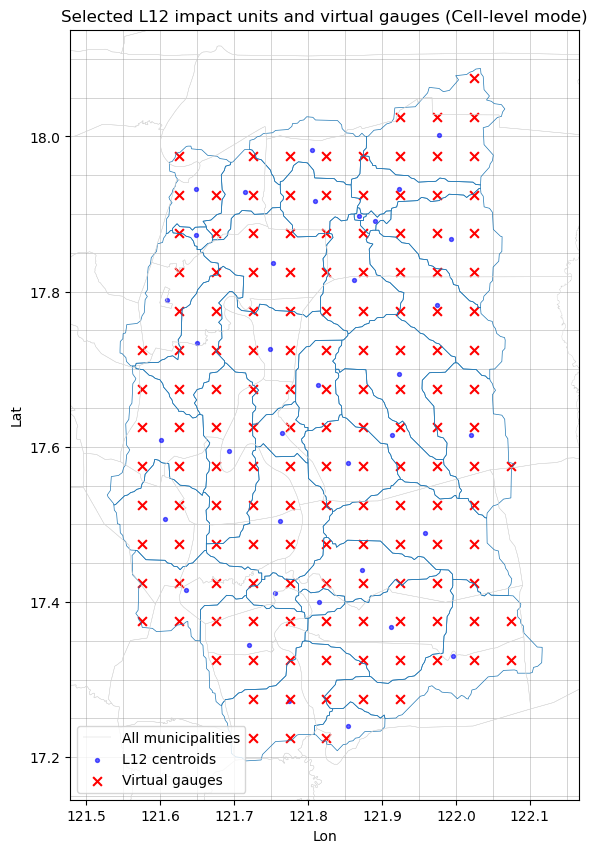

In [10]:
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Open one sample GRIB to get the GloFAS grid
inventory = discover_grib_year_files(glofas_grib_root)
sample_grib = inventory[0].grib_path
ds = open_grib_dataset(sample_grib, index_dir=index_dir)

# Add subtle GloFAS grid behind everything (bbox from selected_l12)
bbox = tuple(selected_l12.geometry.total_bounds)  # Use selected_l12 bounds instead of adm3
add_glofas_grid_overlay(ax, ds, bbox_lonlat=bbox, pad_deg=0.15)

try:
    ds.close()
except Exception:
    pass

# Base: selected L12
selected_l12.boundary.plot(ax=ax, linewidth=0.5)
# ALL municipalities (light background)
adm3_gdf.boundary.plot(ax=ax, linewidth=0.3, color="lightgray", alpha=1, label="All municipalities")

# AOI (if any) - only in municipality mode
if USE_MUNI_AOI:
    aoi_gdf = gpd.GeoDataFrame({"geometry": aoi_geoms}, crs="EPSG:4326")
    aoi_gdf.boundary.plot(ax=ax, linewidth=1.5, color="purple", label="AOI buffer")
    adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)].boundary.plot(ax=ax, linewidth=2.0, color="red", label="Selected municipalities")

# Pour points or cell source points (depends on extraction mode)
if USE_CELL_EXTRACTION:
    # Cell-level: cells_within_polygon doesn't produce pour points, only cell coordinates
    # Show the L12 centroids instead for reference
    l12_centroids = selected_l12.copy()
    l12_centroids['geometry'] = l12_centroids.geometry.centroid
    l12_centroids.plot(ax=ax, markersize=8, color='blue', label='L12 centroids', alpha=0.6)
else:
    # Pour-point mode: show the pour points
    pp = gpd.GeoDataFrame(points_df, geometry=[Point(xy) for xy in zip(points_df.pour_lon, points_df.pour_lat)], crs="EPSG:4326")
    pp.plot(ax=ax, markersize=8, label='Pour points')

# Virtual gauges (unique cells)
vg_unique = points_df.drop_duplicates("virtual_gauge_id").copy()
vg = gpd.GeoDataFrame(vg_unique, geometry=[Point(xy) for xy in zip(vg_unique.lon, vg_unique.lat)], crs="EPSG:4326")
vg.plot(ax=ax, markersize=40, marker="x", color='red', label='Virtual gauges')

ax.set_title(f"Selected L12 impact units and virtual gauges ({'Cell-level' if USE_CELL_EXTRACTION else 'Pour-point'} mode)")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.legend()

# Zoom to selected_l12 bounds (centered, tight)
bounds = selected_l12.geometry.total_bounds
minx, miny, maxx, maxy = bounds
pad = 0.05  # degrees; small padding for tightness
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

plt.show()


## 7) Write mapping tables 

We write:
- municipality → AOI → selected L12 (if AOI mode)
- L12 → pour point
- L12 → virtual gauge (GloFAS cell) + collision sizes


In [12]:
log.section("SECTION 7: Write Mapping Tables")

out_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag
mapping_dir = out_root / "mapping"
aoi_dir = out_root / "aoi"
for d in [mapping_dir, aoi_dir]:
    d.mkdir(parents=True, exist_ok=True)

log.step("Writing mapping tables...")

# A) muni → AOI → L12
if USE_MUNI_AOI:
    muni_aoi_df = pd.DataFrame(muni_aoi_records)
    muni_aoi_df.to_parquet(mapping_dir / "muni_aoi_l12.parquet", index=False)
    log.step(f"Wrote {len(muni_aoi_df)} municipality AOI records")

    # Save AOI geometries
    import geopandas as gpd
    aoi_gdf = gpd.GeoDataFrame(muni_aoi_df[["adm3_id", "centroid_lon", "centroid_lat", "total_population", "valid_pixel_count"]].copy(),
                              geometry=aoi_geoms, crs="EPSG:4326")
    aoi_gdf.to_file(aoi_dir / "municipality_aoi.geojson", driver="GeoJSON")
    log.step(f"Wrote AOI geometries to {aoi_dir}")

# B) L12 → grid cell mapping (adaptive to both extraction modes)
if USE_CELL_EXTRACTION:
    # Cell-level mode: L12 → cells (many cells per L12 possible)
    l12_cells = points_df[["l12_id", "lat", "lon"]].copy()
    l12_cells.to_parquet(mapping_dir / "l12_cell_coordinates.parquet", index=False)
    log.step(f"Wrote {len(l12_cells)} L12↔cell mappings")
else:
    # Pour-point mode: L12 → single pour point → single cell
    l12_pour = points_df[["l12_id", "pour_lon", "pour_lat"]].copy()
    l12_pour.to_parquet(mapping_dir / "l12_pour_points.parquet", index=False)
    log.step(f"Wrote {len(l12_pour)} pour point coordinates")

# C) L12 → virtual gauge (unique cell ID)
l12_vg = points_df[["l12_id", "virtual_gauge_id", "lat", "lon"]].drop_duplicates("virtual_gauge_id").copy()
l12_vg.to_parquet(mapping_dir / "l12_virtual_gauge.parquet", index=False)
log.step(f"Wrote {len(l12_vg)} L12↔virtual gauge mappings")

# D) Virtual gauge collision groups (how many L12s share each cell)
if USE_CELL_EXTRACTION:
    # For cell-level, we already have l12_count in points_df
    vg_collision = points_df[["virtual_gauge_id", "l12_count"]].drop_duplicates("virtual_gauge_id").copy()
else:
    # For pour-point mode, also already computed in Section 5
    vg_collision = points_df[["virtual_gauge_id", "collision_group_size"]].drop_duplicates("virtual_gauge_id").copy()
    vg_collision = vg_collision.rename(columns={"collision_group_size": "l12_count"})

vg_collision.to_parquet(mapping_dir / "virtual_gauge_collision_sizes.parquet", index=False)
log.step(f"Wrote collision group sizes for {len(vg_collision)} virtual gauges")

log.success("Section 7 complete: Mapping tables written")



  SECTION 7: Write Mapping Tables
• Writing mapping tables...
• Wrote 147 L12↔cell mappings
• Wrote 147 L12↔virtual gauge mappings
• Wrote collision group sizes for 147 virtual gauges
✓ Section 7 complete: Mapping tables written


In [13]:
log.section("SECTION 6B: Validate GRIB Files")

from pathlib import Path

bad = []
small = []
ok = 0

log.step("Checking GRIB file integrity...")

for item in inventory:
    p = Path(item.grib_path)
    if not p.exists():
        bad.append((item.year, "MISSING", str(p)))
        continue

    size = p.stat().st_size
    head = p.open("rb").read(4)

    if head != b"GRIB":
        bad.append((item.year, f"NOT_GRIB magic={head!r}", str(p)))
        continue

    if size < 5 * 1024 * 1024:  # <5MB is suspicious for "yearly consolidated discharge"
        small.append((item.year, f"{size/1024**2:.2f} MB", str(p)))
        continue

    ok += 1

log.table("GRIB Integrity Check", {
    "OK files": ok,
    "Missing files": len(bad),
    "Suspiciously small": len(small),
})

if bad:
    log.warn(f"BAD examples: {bad[:5]}")
if small:
    log.warn(f"SMALL examples: {small[:5]}")

log.success("GRIB file validation complete")


  SECTION 6B: Validate GRIB Files
• Checking GRIB file integrity...

GRIB Integrity Check:
  OK files................................ 47
  Missing files........................... 0
  Suspiciously small...................... 0
✓ GRIB file validation complete


## 8) GRIB → daily discharge time series 
We extract only the **unique virtual gauges** needed for this run.

- Auto-detect available years
- Skip already-processed gauge parquet files (unless forced)


In [14]:
# ============================================================================
# 8a) EXTRACTION METHOD CONFIGURATION
# ============================================================================
# Choose extraction method and configure memory optimization.
#
# ⭐ STREAMING EXTRACTION (RECOMMENDED) ⭐
# - Processes one year at a time, writes immediately to disk
# - Constant memory usage regardless of dataset size
# - Scales to country-level deployments (1000s of gauges)
# - Supports resumption if crashes occur
# - Works on cloud and local machines
#
# LEGACY EXTRACTION (Original method)
# - Loads all years into memory, then writes
# - Memory usage grows with years × gauges
# - Uses memory optimization tricks to reduce usage
# - May still crash on large datasets

# ⚠️ CHOOSE ONE:
USE_STREAMING = True  # ← RECOMMENDED: Year-by-year streaming (constant memory)
USE_MEMORY_OPTIMIZATION = True  # ← Only used if USE_STREAMING=False

# Gauge batch size (only for legacy mode when USE_STREAMING=False)
# Streaming mode always processes all gauges per year for efficiency
GAUGE_BATCH_SIZE = 2

# Memory thresholds (only for legacy mode)
MEMORY_WARNING_THRESHOLD = 70.0
MEMORY_ERROR_THRESHOLD = 85.0

print(f"\n{'='*80}")
if USE_STREAMING:
    print(f"⭐ STREAMING EXTRACTION ENABLED (RECOMMENDED)")
    print(f"{'='*80}")
    print(f"  • Architecture:           Year-by-year sequential processing")
    print(f"  • Memory usage:           Constant (only 1 year in RAM at a time)")
    print(f"  • Intermediate files:     Temp parquet per year → merged at end")
    print(f"  • Resumption:             YES (skips already-extracted years)")
    print(f"  • Scales to:              1000s of gauges, 50+ years")
    print(f"  • Recommended for:        All deployments (local & cloud)")
    print(f"{'='*80}\n")
elif USE_MEMORY_OPTIMIZATION:
    print(f"🔧 LEGACY MODE with Memory Optimization")
    print(f"{'='*80}")
    print(f"  • Geographic chunking:    YES (reduce grid size)")
    print(f"  • Gauge batching:         YES (batch size: {GAUGE_BATCH_SIZE})")
    print(f"  • Memory monitoring:      YES (warn: {MEMORY_WARNING_THRESHOLD}%, stop: {MEMORY_ERROR_THRESHOLD}%)")
    print(f"  • Note:                   May still crash on large datasets")
    print(f"{'='*80}\n")
else:
    print(f"⚠️  LEGACY MODE WITHOUT OPTIMIZATION (Not recommended)")
    print(f"{'='*80}\n")


⭐ STREAMING EXTRACTION ENABLED (RECOMMENDED)
  • Architecture:           Year-by-year sequential processing
  • Memory usage:           Constant (only 1 year in RAM at a time)
  • Intermediate files:     Temp parquet per year → merged at end
  • Resumption:             YES (skips already-extracted years)
  • Scales to:              1000s of gauges, 50+ years
  • Recommended for:        All deployments (local & cloud)



In [15]:
log.section("SECTION 8: Extracting Discharge Time Series")

timeseries_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "timeseries" / "virtual_gauges"
timeseries_dir.mkdir(parents=True, exist_ok=True)

# vg_points already created in Section 5, just verify it's set up correctly
if "lat" not in vg_points.columns or "lon" not in vg_points.columns:
    log.error("vg_points missing 'lat' or 'lon' columns!")
    raise KeyError("vg_points missing required columns")

log.table("Extraction Setup", {
    "Unique gauges": len(vg_points),
    "Total GRIB files": len(inventory),
    "Year range": f"{inventory[0].year}–{inventory[-1].year}",
    "Extraction method (spatial)": "Cell-level (all cells within polygon)" if USE_CELL_EXTRACTION else "Pour point (single outlet)",
    "Extraction method (temporal)": "STREAMING (year-by-year)" if USE_STREAMING else ("Memory-optimized" if USE_MEMORY_OPTIMIZATION else "Legacy"),
    "Gauge batch size": GAUGE_BATCH_SIZE if (not USE_STREAMING and USE_MEMORY_OPTIMIZATION) else "N/A",
})

if SELECTED_YEARS is not None:
    filtered_inventory = [i for i in inventory if i.year in SELECTED_YEARS]
    log.warn(f"Processing only {len(filtered_inventory)} selected years: {SELECTED_YEARS}")
else:
    filtered_inventory = inventory

log.step("Extracting discharge (this may take several minutes)...")

# === EXTRACTION WITH DETAILED LOGGING ===
import time
import psutil

start_time = time.time()


  SECTION 8: Extracting Discharge Time Series

Extraction Setup:
  Unique gauges........................... 147
  Total GRIB files........................ 47
  Year range.............................. 1979–2025
  Extraction method (spatial)............. Cell-level (all cells within polygon)
  Extraction method (temporal)............ STREAMING (year-by-year)
  Gauge batch size........................ N/A
• Extracting discharge (this may take several minutes)...


## 10) Interactive threshold selection (choose a gauge and find its POT threshold)

Use this block to pick a virtual gauge, review diagnostics, and lock in the POT threshold that will feed the save/log steps below. Nothing is written to disk in this section.

**Flow**
1. Run the widget to inspect diagnostics for a gauge (auto threshold is highlighted).
2. (Optional) Review candidate threshold stats to override manually.
3. Finalize the threshold to set `threshold_m3s`, `pot`, and `xi_sigma` for the save step.



In [16]:
import math
import numpy as np
import pandas as pd
from pyextremes import EVA

def _dynamic_min_events_total(
    coverage_years: float,
    target_lambda_rse: float = 0.20,   # 20% relative SE on lambda -> ~25 events
    min_floor: int = 10,
    max_events_per_year: float = 6.0,  # cap so short records don't force too-low thresholds
    want_gpd_params: bool = True,
):
    # For Poisson counts N ~ Pois(lambda*T), RSE(lambda_hat) ~ 1/sqrt(N)
    n_rate = math.ceil(1.0 / (target_lambda_rse ** 2))  # 0.20 -> 25
    n_gpd = 50 if want_gpd_params else 0               # classic heuristic for stable GPD params
    n_req = max(min_floor, n_rate, n_gpd)
    n_cap = max(min_floor, math.ceil(max_events_per_year * max(coverage_years, 0.0)))
    n_final = min(n_req, n_cap)
    status = "ok" if n_final == n_req else "capped_short_record"
    return int(n_final), status

def _get_fit_params(eva: EVA):
    """Robustly read fitted params from pyextremes model."""
    model = getattr(eva, "model", None)
    if model is None:
        return None
    # documented property
    fitp = getattr(model, "fit_parameters", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    # fallback (some versions expose params)
    fitp = getattr(model, "params", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    return None

def auto_select_threshold_pot(
    s: pd.Series,
    candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
    run_length_days: int = 5,
    min_events_total: int | str = "auto",          # int or "auto"
    target_lambda_range: tuple[float, float] | None = (1.0, 4.0),  # set None to disable
    stability_k: int = 3,                           # require stable region across k thresholds
    stability_tol_xi: float = 0.15,                 # abs range of xi within window
    stability_tol_sigma: float = 0.35,              # relative range of sigma within window
    dispersion_range: tuple[float, float] | None = (0.5, 2.0),
    dispersion_hard: bool = False,                  # False -> flag only; True -> gate
    require_gpd_params: bool = False,                # if True, thresholds without xi/sigma never pass
    verbose: bool = False,
):
    """
    Select the smallest threshold that yields declustered POT extremes consistent with GPD
    (operationalized via parameter-stability over a window) plus minimum event sufficiency.
    This follows the standard threshold-selection goal: pick the smallest threshold in a stable tail regime. :contentReference[oaicite:3]{index=3}
    """
    s = s.dropna().sort_index()
    if len(s) < 30 or not isinstance(s.index, pd.DatetimeIndex):
        raise ValueError("Input series must be a non-empty daily Series with a DatetimeIndex.")

    years = np.arange(s.index.min().year, s.index.max().year + 1)
    coverage_years = float(len(s) / 365.25)

    # Dynamic min events (optional)
    min_events_status = "fixed"
    if isinstance(min_events_total, str) and min_events_total.lower() == "auto":
        min_events_total, min_events_status = _dynamic_min_events_total(
            coverage_years=coverage_years,
            want_gpd_params=require_gpd_params,
        )

    thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
    r = f"{int(run_length_days)}D"

    eva = EVA(s)  # reuse for speed; get_extremes resets internal state
    rows = []

    for u in thresholds:
        eva.get_extremes(method="POT", threshold=float(u), r=r, extremes_type="high")
        ev = eva.extremes

        annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
        lam = float(annual.mean())
        disp = float((annual.var(ddof=1) / annual.mean())) if annual.mean() > 0 else np.nan

        xi = sigma = np.nan
        fit_ok = False
        try:
            eva.fit_model(distribution="genpareto")
            fit_params = _get_fit_params(eva)
            if isinstance(fit_params, dict):
                xi = float(fit_params.get("shape", fit_params.get("c", np.nan)))
                sigma = float(fit_params.get("scale", np.nan))
                fit_ok = (not np.isnan(xi)) and (not np.isnan(sigma)) and (sigma > 0)
        except Exception:
            fit_ok = False

        rows.append({
            "threshold": float(u),
            "n_events": int(len(ev)),
            "coverage_years": coverage_years,
            "lambda_per_year": lam,
            "dispersion_var_over_mean": disp,
            "xi": xi,
            "sigma": sigma,
            "gpd_fit_ok": bool(fit_ok),
        })

    df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

    # --- build pass flags ---
    df["meets_events"] = df["n_events"] >= int(min_events_total)

    if target_lambda_range is None:
        df["meets_lambda"] = True
    else:
        lo, hi = target_lambda_range
        df["meets_lambda"] = (df["lambda_per_year"] >= lo) & (df["lambda_per_year"] <= hi)

    if dispersion_range is None:
        df["meets_dispersion"] = True
    else:
        dlo, dhi = dispersion_range
        df["meets_dispersion"] = df["dispersion_var_over_mean"].between(dlo, dhi, inclusive="both")

    # Parameter stability over a rolling window of size k
    df["stable_k"] = False
    for i in range(len(df)):
        j0 = i - (stability_k - 1)
        if j0 < 0:
            continue
        win = df.loc[j0:i, ["xi", "sigma", "gpd_fit_ok"]]
        if require_gpd_params and (not win["gpd_fit_ok"].all()):
            continue
        if win["xi"].isna().any() or win["sigma"].isna().any():
            continue
        xi_range = float(win["xi"].max() - win["xi"].min())
        sigma_min = float(win["sigma"].min())
        sigma_max = float(win["sigma"].max())
        sigma_rel = (sigma_max / sigma_min - 1.0) if sigma_min > 0 else np.inf

        if (xi_range <= stability_tol_xi) and (sigma_rel <= stability_tol_sigma):
            df.at[i, "stable_k"] = True

    # Final pass logic
    if dispersion_hard:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["meets_dispersion"] & df["stable_k"]
    else:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["stable_k"]
        # still keep dispersion as QC flag
        df["dispersion_flag"] = ~df["meets_dispersion"]

    # Pick the smallest threshold in a stable region
    if df["passes"].any():
        pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
        status = "ok"
    else:
        # fallback: pick smallest threshold that at least meets events (or highest threshold if nothing meets)
        if df["meets_events"].any():
            pick = float(df.loc[df["meets_events"]].iloc[0]["threshold"])
            status = "fallback_events_only_no_stable_region"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"

    if verbose:
        print(f"[auto_select_threshold_pot] min_events_total={min_events_total} ({min_events_status}), "
              f"target_lambda_range={target_lambda_range}, stability_k={stability_k}, status={status}, pick={pick:.2f}")

    # store key config in attrs for traceability
    df.attrs = {
        "run_length_days": int(run_length_days),
        "min_events_total": int(min_events_total),
        "min_events_status": min_events_status,
        "target_lambda_range": target_lambda_range,
        "stability_k": int(stability_k),
        "stability_tol_xi": float(stability_tol_xi),
        "stability_tol_sigma": float(stability_tol_sigma),
        "dispersion_range": dispersion_range,
        "dispersion_hard": bool(dispersion_hard),
        "require_gpd_params": bool(require_gpd_params),
    }

    return pick, status, df


In [17]:
# ============================================================================
# 8a) DISCHARGE TIME SERIES EXTRACTION
# ============================================================================
# Extract discharge data for all virtual gauges from GRIB files
# Using streaming mode for memory efficiency

log.section("SECTION 8A: Time Series Extraction")

# Prepare extraction parameters
series_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag / "timeseries"
cfgrib_index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

log.step("Extracting daily discharge from GRIB files...")
log.step(f"Output directory: {series_root}")

# Call extraction function with streaming enabled
series_by_gauge = load_or_build_gauge_timeseries(
    grib_inventory=filtered_inventory,
    points=vg_points,
    processed_timeseries_dir=series_root,
    cfgrib_index_dir=cfgrib_index_dir,
    force=False,  # use cached if available
    discharge_var=discharge_var,
    selected_years=SELECTED_YEARS,
    use_streaming=USE_STREAMING,
    use_memory_optimization=USE_MEMORY_OPTIMIZATION,
    gauge_batch_size=GAUGE_BATCH_SIZE,
)

log.success(f"Section 8A complete: Extracted {len(series_by_gauge)} gauge time series")


  SECTION 8A: Time Series Extraction
• Extracting daily discharge from GRIB files...
• Output directory: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\timeseries
✓ Section 8A complete: Extracted 147 gauge time series


In [18]:
import numpy as np
import pandas as pd
from pathlib import Path

from pyextremes import EVA

# Ensure helper is available even if previous cell was skipped
try:
    auto_select_threshold_pot
except NameError:
    from pyextremes import EVA as _EVA
    def auto_select_threshold_pot(
        s: pd.Series,
        candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
        run_length_days=5,
        min_events_total=50,
        stability_tol_xi=0.15,
        stability_tol_sigma=0.35,
        dispersion_range=(0.5, 2.0),
        verbose=False,
    ):
        if verbose:
            print(f"[auto_select_threshold_pot] Received parameters:")
            print(f"  candidate_quantiles: {candidate_quantiles}")
            print(f"  run_length_days: {run_length_days}")
            print(f"  min_events_total: {min_events_total}")
            print(f"  stability_tol_xi: {stability_tol_xi}")
            print(f"  stability_tol_sigma: {stability_tol_sigma}")
            print(f"  dispersion_range: {dispersion_range}")
        s = s.dropna().sort_index()
        years = np.arange(s.index.min().year, s.index.max().year + 1)
        thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
        rows = []
        prev_xi = prev_sigma = None
        for u in thresholds:
            eva = _EVA(s)
            eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
            ev = eva.extremes
            annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
            lam = annual.mean()
            disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
            xi = sigma = np.nan
            try:
                eva.fit_model(distribution="genpareto")
                params = getattr(getattr(eva, "model", None), "params", None)
                if isinstance(params, dict):
                    xi = float(params.get("shape", params.get("c", np.nan)))
                    sigma = float(params.get("scale", np.nan))
            except Exception:
                pass
            stable = True
            if prev_xi is not None and not np.isnan(xi) and not np.isnan(prev_xi):
                stable &= (abs(xi - prev_xi) <= stability_tol_xi)
            if prev_sigma is not None and not np.isnan(sigma) and not np.isnan(prev_sigma) and prev_sigma > 0:
                stable &= (abs((sigma / prev_sigma) - 1.0) <= stability_tol_sigma)
            passes = ((len(ev) >= min_events_total) and (dispersion_range[0] <= disp <= dispersion_range[1]) and stable)
            rows.append({
                "threshold": u,
                "n_events": int(len(ev)),
                "lambda_per_year": float(lam),
                "dispersion_var_over_mean": float(disp) if disp == disp else np.nan,
                "xi": float(xi) if xi == xi else np.nan,
                "sigma": float(sigma) if sigma == sigma else np.nan,
                "stable_vs_prev": bool(stable),
                "passes": bool(passes),
            })
            prev_xi, prev_sigma = xi, sigma
        df = pd.DataFrame(rows).sort_values("threshold")
        if df["passes"].any():
            pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
            status = "ok"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"
        return pick, status, df

# ============================================================================
# BATCH PROCESSING: Generate diagnostic stats + auto-select thresholds
# for ALL gauges. This runs once to populate the results folder.
# ============================================================================

# --- Calibration config (centralized for consistency across all Section 10 cells) ---
RUN_LENGTH_DAYS = int(run_length_days)  # uses notebook variable from Section 1
CANDIDATE_QUANTILES = candidate_quantiles if "candidate_quantiles" in globals() else (0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99)
MIN_EVENTS_TOTAL = "auto"  # minimum events required for a threshold to pass
STABILITY_TOL_XI = 0.15
STABILITY_TOL_SIGMA = 0.35
DISPERSION_RANGE = (0.5, 2.0)

MIN_EVENTS_TOTAL = "auto"              # <- dynamic per gauge
TARGET_LAMBDA_RANGE = (1.0, 4.0)       # <- optional; set None to disable
STABILITY_K = 3
DISPERSION_HARD = False               # <- keep dispersion as flag for now

# Output location
diag_root = (out_root / "results" / "diagnostics_by_gauge") if "out_root" in globals() else Path("./results/diagnostics_by_gauge")
diag_root.mkdir(parents=True, exist_ok=True)

print(f"=" * 70)
print(f"BATCH DIAGNOSTICS CONFIG:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}")
print(f"=" * 70)

summary_rows = []

gauge_ids = sorted(series_by_gauge.keys())
print(f"\nGenerating diagnostics for {len(gauge_ids)} gauge(s)…")
print(f"Output folder: {diag_root.resolve()}\n")

for i, gid in enumerate(gauge_ids, start=1):
    s = series_by_gauge[gid].dropna().sort_index()
    if len(s) == 0:
        continue

    coverage_years = float(len(s) / 365.25)
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        target_lambda_range=TARGET_LAMBDA_RANGE,
        stability_k=STABILITY_K,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        dispersion_hard=DISPERSION_HARD,
        require_gpd_params=True,
        verbose=False,
)

    gdir = diag_root / gid
    gdir.mkdir(parents=True, exist_ok=True)

    # Save diagnostics table per gauge
    diag_df.to_parquet(gdir / "threshold_diagnostics.parquet", index=False)

    summary_rows.append({
        "virtual_gauge_id": gid,
        "coverage_years": coverage_years,
        "q95_m3s": q95,
        "u_auto_m3s": float(pick_u),
        "auto_status": pick_status,
        "n_events_at_u_auto": int(diag_df.loc[diag_df["threshold"] == pick_u, "n_events"].iloc[0]) if (diag_df["threshold"] == pick_u).any() else np.nan,
        "auto_status": pick_status,
        "dispersion_flag_at_pick": bool(diag_df.loc[diag_df["threshold"] == pick_u, "dispersion_flag"].iloc[0]) if "dispersion_flag" in diag_df.columns else False,
    })

    if i % 10 == 0 or i == len(gauge_ids):
        print(f"  [{i}/{len(gauge_ids)}] done")

# Save aggregate summary
summary_df = pd.DataFrame(summary_rows).sort_values(["auto_status", "coverage_years"], ascending=[True, False])
summary_df.to_parquet(diag_root / "_summary.parquet", index=False)
print(f"\n✓ Batch diagnostics complete. Summary saved to: {diag_root / '_summary.parquet'}")
display(summary_df.head(20))


BATCH DIAGNOSTICS CONFIG:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)

Generating diagnostics for 147 gauge(s)…
Output folder: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\diagnostics_by_gauge

  [10/147] done
  [20/147] done
  [30/147] done
  [40/147] done
  [50/147] done
  [60/147] done
  [70/147] done
  [80/147] done
  [90/147] done
  [100/147] done
  [110/147] done
  [120/147] done
  [130/147] done
  [140/147] done
  [147/147] done

✓ Batch diagnostics complete. Summary saved to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\diagnostics_by_gauge\_summary.parquet


,virtual_gauge_id,coverage_years,q95_m3s,u_auto_m3s,auto_status,n_events_at_u_auto,dispersion_flag_at_pick
0,CELL__lat_17.2250__lon_121.7250,46.833676,4.296875,5.390625,ok,175,False
1,CELL__lat_17.2250__lon_121.7750,46.833676,185.085938,203.037500,ok,188,False
2,CELL__lat_17.2250__lon_121.8250,46.833676,2672.259766,2672.259766,ok,185,False
3,CELL__lat_17.2750__lon_121.7250,46.833676,4.591797,5.750000,ok,182,False
4,CELL__lat_17.2750__lon_121.7750,46.833676,13.718750,17.276562,ok,180,False
5,CELL__lat_17.2750__lon_121.8250,46.833676,2721.667969,2721.667969,ok,184,False
6,CELL__lat_17.2750__lon_121.8750,46.833676,49.585938,65.078125,ok,160,False
7,CELL__lat_17.2750__lon_121.9250,46.833676,45.273438,59.026172,ok,161,False
8,CELL__lat_17.3250__lon_121.6750,46.833676,4.531250,5.718750,ok,174,False
9,CELL__lat_17.3250__lon_121.7250,46.833676,22.646484,28.617969,ok,174,False


In [19]:
# ============================================================================
# STEP 1: Select a gauge and view diagnostics + auto-recommended threshold
# ============================================================================
import logging
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pyextremes import EVA, plot_mean_residual_life, plot_parameter_stability
from pyextremes.plotting.extremes import plot_extremes

logging.getLogger("pyextremes").setLevel(logging.WARNING)

print(f"Using config from batch processing cell:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}\n")


def _plot_mrl(s, q95, pick_u):
    plot_mean_residual_life(s)
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title("Mean Residual Life")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_parameter_stability(s, q95, pick_u):
    thr_grid = np.linspace(float(s.quantile(0.90)), float(s.quantile(0.995)), 40)
    plot_parameter_stability(s, thresholds=thr_grid, r=f"{RUN_LENGTH_DAYS}D")
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title(f"Parameter stability (r={RUN_LENGTH_DAYS}D)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_pot_extremes(s, pick_u):
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(pick_u), r=f"{RUN_LENGTH_DAYS}D", extremes_type="high")
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_extremes(
        ts=s,
        extremes=eva.extremes,
        extremes_method="POT",
        extremes_type="high",
        threshold=float(pick_u),
        r=f"{RUN_LENGTH_DAYS}D",
        ax=ax,
    )
    ax.set_title(f"POT extremes (u*={pick_u:.2f}, r={RUN_LENGTH_DAYS}D)")
    plt.tight_layout()
    plt.show()


def show_gauge_diag(gid):
    """Display diagnostics for a selected gauge and store selection globally."""
    global selected_gauge_id, diag_df
    selected_gauge_id = gid
    s = series_by_gauge[gid].dropna().sort_index()
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=True,  # Show diagnostic info
    )

    _plot_mrl(s, q95, pick_u)
    _plot_parameter_stability(s, q95, pick_u)
    _plot_pot_extremes(s, pick_u)

    print(f"\nAUTO threshold selection: {pick_status}")
    print(f"Picked threshold: {pick_u:.2f} m³/s")
    display(diag_df)


if HAS_WIDGETS:
    dropdown = widgets.Dropdown(options=sorted(series_by_gauge.keys()), description="Gauge:")
    ui = widgets.interactive(show_gauge_diag, gid=dropdown)
    display(ui)
else:
    fallback_gid = sorted(series_by_gauge.keys())[0]
    print(f"Widgets not available. Using first gauge: {fallback_gid}")
    show_gauge_diag(fallback_gid)


Using config from batch processing cell:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)



interactive(children=(Dropdown(description='Gauge:', options=('CELL__lat_17.2250__lon_121.7250', 'CELL__lat_17…

## 11D) Stakeholder Visualization: Return Level Curves

Presents return level analysis results in professional, publication-ready format for stakeholders and decision-makers.

In [23]:
"""
Section 11D: Stakeholder Return Level Curves

Creates professional visualizations of return level analysis for stakeholders:
1. Representative gauge return level curves with confidence intervals
2. Basin-wide return level statistics
3. Coefficient of variation trends
4. Summary statistics table
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

log.section("SECTION 11D: Stakeholder Return Level Curves")

# Define output directories
fig_dir = out_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Load bootstrap return levels
bootstrap_file = out_root / "return_levels" / "return_levels_bootstrap.parquet"

if not bootstrap_file.exists():
    log.error(f"Bootstrap return levels file not found: {bootstrap_file}")
    log.warn("Please run Section 11C first")
else:
    log.step("Loading bootstrap return levels...")
    rl_df = pd.read_parquet(bootstrap_file)
    
    # Set professional styling
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['legend.fontsize'] = 10
    
    # Create figure with 2×2 layout
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # --- Panel 1: Representative Gauge Return Level Curves ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    log.step("Creating return level curves for representative gauges...")
    
    # Select 5-7 representative gauges (stratified by discharge magnitude)
    gauge_stats = rl_df.groupby("virtual_gauge_id")["return_level_m3s_mean"].agg(["mean", "max"]).reset_index()
    gauge_stats = gauge_stats.sort_values("max")
    
    # Select gauges at different percentiles (10th, 25th, 50th, 75th, 90th)
    percentiles = [10, 25, 50, 75, 90]
    selected_gauges = [
        gauge_stats.iloc[int(len(gauge_stats) * p / 100)]["virtual_gauge_id"]
        for p in percentiles
    ]
    
    # Use colorblind-friendly palette
    colors = sns.color_palette("Set2", n_colors=len(selected_gauges))
    
    for idx, gauge_id in enumerate(selected_gauges):
        gauge_data = rl_df[rl_df["virtual_gauge_id"] == gauge_id].sort_values("return_period_years")
        
        if len(gauge_data) == 0:
            continue
        
        # Extract data
        rps = gauge_data["return_period_years"].values
        mean_rl = gauge_data["return_level_m3s_mean"].values
        q05 = gauge_data["return_level_m3s_q05"].values
        q95 = gauge_data["return_level_m3s_q95"].values
        
        # Plot mean with confidence interval
        ax1.plot(rps, mean_rl, '-o', color=colors[idx], linewidth=2, 
                 markersize=6, label=f"Gauge {gauge_id}", zorder=3)
        ax1.fill_between(rps, q05, q95, color=colors[idx], alpha=0.2, zorder=2)
    
    ax1.set_xscale('log')
    ax1.set_xlabel('Return Period (years)', fontweight='bold')
    ax1.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax1.set_title('Return Level Curves (Representative Gauges)', fontweight='bold', pad=10)
    ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, which='both', alpha=0.3, linestyle='--')
    ax1.set_xlim(left=1)
    
    # --- Panel 2: Basin-Wide Return Level Statistics ---
    ax2 = fig.add_subplot(gs[0, 1])
    
    log.step("Computing basin-wide return level statistics...")
    
    # Compute statistics across all gauges for each return period
    rp_stats = rl_df.groupby("return_period_years").agg({
        "return_level_m3s_mean": ["mean", "median", "std", "min", "max"],
    }).reset_index()
    rp_stats.columns = ["return_period", "mean", "median", "std", "min", "max"]
    
    rps = rp_stats["return_period"].values
    
    # Plot mean and median with ribbons
    ax2.plot(rps, rp_stats["mean"], '-o', color='#E74C3C', linewidth=2.5, 
             markersize=7, label='Basin Mean', zorder=3)
    ax2.plot(rps, rp_stats["median"], '--s', color='#3498DB', linewidth=2, 
             markersize=6, label='Basin Median', zorder=3)
    
    # Add min/max range as ribbon
    ax2.fill_between(rps, rp_stats["min"], rp_stats["max"], 
                     color='gray', alpha=0.2, label='Min-Max Range', zorder=1)
    
    # Add ±1 std ribbon around mean
    ax2.fill_between(rps, 
                     rp_stats["mean"] - rp_stats["std"],
                     rp_stats["mean"] + rp_stats["std"],
                     color='#E74C3C', alpha=0.2, label='±1 Std Dev', zorder=2)
    
    ax2.set_xscale('log')
    ax2.set_xlabel('Return Period (years)', fontweight='bold')
    ax2.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax2.set_title('Basin-Wide Return Level Statistics', fontweight='bold', pad=10)
    ax2.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax2.grid(True, which='both', alpha=0.3, linestyle='--')
    ax2.set_xlim(left=1)
    
    # --- Panel 3: Coefficient of Variation Trends ---
    ax3 = fig.add_subplot(gs[1, 0])
    
    log.step("Analyzing coefficient of variation trends...")
    
    # Compute CV for each gauge and return period
    rl_df["cv"] = rl_df["return_level_m3s_std"] / rl_df["return_level_m3s_mean"]
    
    # Basin-wide CV statistics
    cv_stats = rl_df.groupby("return_period_years")["cv"].agg(["mean", "median", "std"]).reset_index()
    
    # Violin plot of CV distribution by return period
    rp_categories = sorted(rl_df["return_period_years"].unique())
    cv_data = [rl_df[rl_df["return_period_years"] == rp]["cv"].dropna() for rp in rp_categories]
    
    parts = ax3.violinplot(cv_data, positions=range(len(rp_categories)), 
                           showmeans=True, showmedians=True, widths=0.7)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(plt.cm.viridis(i / len(rp_categories)))
        pc.set_alpha(0.7)
    
    ax3.set_xticks(range(len(rp_categories)))
    ax3.set_xticklabels([str(int(rp)) for rp in rp_categories], rotation=45)
    ax3.set_xlabel('Return Period (years)', fontweight='bold')
    ax3.set_ylabel('Coefficient of Variation', fontweight='bold')
    ax3.set_title('Uncertainty Distribution Across Return Periods', fontweight='bold', pad=10)
    ax3.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax3.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='10% CV threshold')
    ax3.legend(loc='upper right')
    
    # --- Panel 4: Summary Statistics Table ---
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    
    log.step("Creating summary statistics table...")
    
    # Prepare table data
    table_data = []
    for rp in rp_categories:
        rp_data = rl_df[rl_df["return_period_years"] == rp]
        
        row = [
            f"{int(rp)}yr",
            f"{rp_data['return_level_m3s_mean'].mean():.1f}",
            f"{rp_data['return_level_m3s_mean'].median():.1f}",
            f"{rp_data['return_level_m3s_mean'].std():.1f}",
            f"{rp_data['cv'].mean():.3f}",
            f"{rp_data['cv'].median():.3f}",
        ]
        table_data.append(row)
    
    col_labels = ["Return\\nPeriod", "Mean\\nDischarge\\n(m³/s)", "Median\\nDischarge\\n(m³/s)", 
                  "Std Dev\\n(m³/s)", "Mean\\nCV", "Median\\nCV"]
    
    table = ax4.table(cellText=table_data, colLabels=col_labels,
                     cellLoc='center', loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header row
    for i in range(len(col_labels)):
        cell = table[(0, i)]
        cell.set_facecolor('#34495E')
        cell.set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(len(col_labels)):
            cell = table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#ECF0F1')
            else:
                cell.set_facecolor('white')
    
    ax4.set_title('Basin-Wide Summary Statistics', fontweight='bold', pad=20, fontsize=14)
    
    # Overall figure title
    fig.suptitle(
        f'Return Level Analysis: {basin_cfg.basin_id}\\nPOT/GPD with Bootstrap Uncertainty (N=20)',
        fontsize=16, fontweight='bold', y=0.98
    )
    
    # Add metadata footer
    metadata_text = (
        f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  |  "
        f"Gauges: {len(rl_df['virtual_gauge_id'].unique())}  |  "
        f"Method: Peaks-over-Threshold with GPD  |  "
        f"Bootstrap Samples: 20"
    )
    fig.text(0.5, 0.01, metadata_text, ha='center', fontsize=9, 
             style='italic', color='gray')
    
    # Save figure
    curves_path = fig_dir / "stakeholder_return_level_curves.png"
    fig.savefig(curves_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    
    log.success(f"✓ Stakeholder curves saved: {curves_path.name}")
    
    # Summary report
    log.table("Section 11D Summary", {
        "Figure": curves_path.name,
        "Panels": "4 (curves, basin stats, CV trends, summary table)",
        "Representative gauges": len(selected_gauges),
        "Return periods analyzed": len(rp_categories),
        "Total gauges": len(rl_df["virtual_gauge_id"].unique()),
        "Mean CV (all)": f"{rl_df['cv'].mean():.3f}",
        "Median CV (all)": f"{rl_df['cv'].median():.3f}",
    })

log.success("Section 11D complete ✓")


  SECTION 11D: Stakeholder Return Level Curves
• Loading bootstrap return levels...
• Creating return level curves for representative gauges...
• Computing basin-wide return level statistics...
• Analyzing coefficient of variation trends...
• Creating summary statistics table...
✓ ✓ Stakeholder curves saved: stakeholder_return_level_curves.png

Section 11D Summary:
  Figure.................................. stakeholder_return_level_curves.png
  Panels.................................. 4 (curves, basin stats, CV trends, summary table)
  Representative gauges................... 5
  Return periods analyzed................. 9
  Total gauges............................ 147
  Mean CV (all)........................... 0.110
  Median CV (all)......................... 0.089
✓ Section 11D complete ✓


In [24]:
# STEP 2 (Optional): Review all candidate thresholds for manual override
# This table shows statistics for different threshold choices
# Usually, you'll accept the auto-selected threshold from the widget above

import pandas as pd
import numpy as np
from pyextremes import EVA

s = series_by_gauge[selected_gauge_id].dropna().sort_index()

print(f"Computing threshold statistics for: {selected_gauge_id}")
print(f"Using RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")


def pot_stats(s, u, run_length_days):
    """Calculate POT statistics for a given threshold."""
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
    ev = eva.extremes
    years = np.arange(s.index.min().year, s.index.max().year + 1)
    annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
    lam = annual.mean()
    disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
    return dict(
        threshold=float(u),
        n_events=int(len(ev)),
        lambda_per_year=float(lam),
        dispersion=float(disp) if disp == disp else np.nan,
    )


cand = sorted({float(s.quantile(q)) for q in CANDIDATE_QUANTILES})
rows = [pot_stats(s, u, RUN_LENGTH_DAYS) for u in cand]
threshold_table = pd.DataFrame(rows).sort_values("threshold")
print("Candidate thresholds and their event counts:")
display(threshold_table)


Computing threshold statistics for: CELL__lat_17.2250__lon_121.7250
Using RUN_LENGTH_DAYS=5, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

Candidate thresholds and their event counts:


,threshold,n_events,lambda_per_year,dispersion
0,2.824219,330,7.021277,0.888538
1,3.015625,317,6.744681,0.853930
2,3.250000,307,6.531915,0.791106
3,3.515625,277,5.893617,0.901742
4,3.843750,256,5.446809,1.108016
5,4.296875,236,5.021277,1.112564
6,4.809375,208,4.425532,1.196070
7,5.390625,175,3.723404,1.140870
8,6.513281,129,2.744681,0.973711
9,8.616797,74,1.574468,0.793772


In [25]:
# STEP 3: Finalize threshold (use auto-selected or override manually)
# Set `threshold_override` to a float to bypass the auto-picked value.

threshold_override = None  # e.g., 250.0 to manually override

print(f"Finalizing threshold for: {selected_gauge_id}")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}")
if threshold_override is not None:
    print(f"⚠️  MANUAL OVERRIDE: Using threshold_m3s={threshold_override}")

pick_u, pick_status, diag_df = auto_select_threshold_pot(
    s,
    candidate_quantiles=CANDIDATE_QUANTILES,
    run_length_days=RUN_LENGTH_DAYS,
    min_events_total=MIN_EVENTS_TOTAL,
    stability_tol_xi=STABILITY_TOL_XI,
    stability_tol_sigma=STABILITY_TOL_SIGMA,
    dispersion_range=DISPERSION_RANGE,
    verbose=False,
)

threshold_m3s = float(threshold_override) if threshold_override is not None else pick_u
pot = pot_extract(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)
xi_sigma = fit_gpd_to_pot(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)

print(f"\n{'='*60}")
print(f"FINAL RESULTS FOR: {selected_gauge_id}")
print(f"{'='*60}")
print(f"Selected threshold: {threshold_m3s:.2f} m³/s ({pick_status})")
if threshold_override is not None:
    print(f"  (MANUAL override, auto picked: {pick_u:.2f})")
print(f"Flood events found: {len(pot.events)}")
print(f"Lambda (avg events/year): {pot.lambda_events_per_year:.3f}")
print(f"Data coverage: {pot.coverage_years:.1f} years")
if xi_sigma:
    print(f"GPD shape (xi): {xi_sigma[0]:.4f}")
    print(f"GPD scale (sigma): {xi_sigma[1]:.4f}")
print(f"{'='*60}")


Finalizing threshold for: CELL__lat_17.2250__lon_121.7250
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto

FINAL RESULTS FOR: CELL__lat_17.2250__lon_121.7250
Selected threshold: 5.39 m³/s (ok)
Flood events found: 175
Lambda (avg events/year): 3.737
Data coverage: 46.8 years
GPD shape (xi): -0.0182
GPD scale (sigma): 3.7247


### How the automatic threshold selection works (non-technical explanation)

**The goal:** Find the best river discharge level to identify "flood" events

**The method:**
1. Tests different possible thresholds (from 90th to 99.9th percentile of flow)
2. For each threshold, calculates how many flood events it finds
3. Checks if the statistical model is **stable** (parameters don't jump around wildly)
4. Picks the **lowest threshold** that still has a stable model

**Why this matters:**
- Too LOW a threshold = every small rise is called a "flood" (too many false alarms)
- Too HIGH a threshold = miss real flood events (not enough data to fit model)
- We want the sweet spot: reliable statistics with meaningful flood events

**Technical detail:** Uses GPD (Generalized Pareto Distribution) and checks for stability in shape (ξ) and scale (σ) parameters across adjacent thresholds.

## 11) Save & Validate POT Calibration Outputs

**What this section does:** Extracts "extreme flood events" (called POT events) from the river discharge data.

**In plain language:**
- Uses the best threshold from Section 10 to find significant river events
- Saves each event with its date and discharge level
- Fits a mathematical model to describe how rare extreme events are
- Creates 4 output files: one for each monitoring station

**Outputs you'll see:**
- Event files with flood peaks
- A table with threshold values and statistical parameters
- Quality checks to make sure everything looks reasonable


In [26]:
events_dir = out_root / "events"
results_dir = out_root / "results"
logs_dir = out_root / "logs"
for d in [events_dir, results_dir, logs_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Optional manual overrides per gauge (populate manually as needed)
# Example: MANUAL_THRESHOLD_OVERRIDES = {"VG__lat_12.3456__lon_98.7654": 250.0}
MANUAL_THRESHOLD_OVERRIDES = {}

print("Saving POT events and results for ALL gauges…")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")

result_rows = []

for idx, (gid, s_raw) in enumerate(series_by_gauge.items(), start=1):
    s = s_raw.dropna().sort_index()
    if len(s) == 0:
        print(f"[{idx}/{len(series_by_gauge)}] {gid}: skipped (no data)")
        continue

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=False,
    )

    threshold_use = MANUAL_THRESHOLD_OVERRIDES.get(gid, pick_u)
    threshold_source = "manual_override" if gid in MANUAL_THRESHOLD_OVERRIDES else pick_status

    extraction_metadata = {
        'extraction_method': 'cell-level' if USE_CELL_EXTRACTION else 'pour-point',
        'context_mode': 'municipality-aoi' if USE_MUNI_AOI else 'context-basin',
    }
    pot_res = pot_extract(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS,
                          extraction_method=extraction_metadata['extraction_method'],
                          extraction_metadata=extraction_metadata)
    xi_sigma_local = fit_gpd_to_pot(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS)

    # Save events for this gauge
    pot_events_path = events_dir / f"{gid}__pot_events.parquet"
    pot_res.events.to_parquet(pot_events_path, index=False)

    result_rows.append({
        "virtual_gauge_id": gid,
        "threshold_m3s": pot_res.threshold_m3s,
        "threshold_source": threshold_source,
        "run_length_days": pot_res.run_length_days,
        "lambda_events_per_year": pot_res.lambda_events_per_year,
        "coverage_years": pot_res.coverage_years,
        "gpd_xi": float(xi_sigma_local[0]) if xi_sigma_local else None,
        "gpd_sigma": float(xi_sigma_local[1]) if xi_sigma_local else None,
    })

    if idx % 10 == 0 or idx == len(series_by_gauge):
        print(f"  [{idx}/{len(series_by_gauge)}] saved events + result row")

# Append/update aggregated results table
results_path = results_dir / "evt_pot_calibration.parquet"
if results_path.exists():
    existing = pd.read_parquet(results_path)
    # Drop rows for gauges we are overwriting in this run
    keep = existing[~existing["virtual_gauge_id"].isin([r["virtual_gauge_id"] for r in result_rows])]
    result_df = pd.concat([keep, pd.DataFrame(result_rows)], ignore_index=True)
else:
    result_df = pd.DataFrame(result_rows)

result_df.to_parquet(results_path, index=False)
print("\n✓ Wrote aggregated results:", results_path)
print("✓ Events directory:", events_dir)


Saving POT events and results for ALL gauges…
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

  [10/147] saved events + result row
  [20/147] saved events + result row
  [30/147] saved events + result row
  [40/147] saved events + result row
  [50/147] saved events + result row
  [60/147] saved events + result row
  [70/147] saved events + result row
  [80/147] saved events + result row
  [90/147] saved events + result row
  [100/147] saved events + result row
  [110/147] saved events + result row
  [120/147] saved events + result row
  [130/147] saved events + result row
  [140/147] saved events + result row
  [147/147] saved events + result row

✓ Wrote aggregated results: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\evt_pot_calibration.parquet
✓ Events directory: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\

## 11b) QA — Verify POT calibration outputs

Quick validation of saved calibration results:
- Aggregated threshold & GPD parameter table
- Per-gauge event files with extracted POT events
- Summary statistics for all gauges


In [27]:
"""
Section 11b QA: Verify all POT calibration outputs were saved correctly.
Displays:
  - Aggregated results (one row per gauge)
  - List of event files
  - Sample event records from first gauge
"""

from pathlib import Path
import pandas as pd

print("=" * 90)
print("SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs")
print("=" * 90)

# Load aggregated results
results_path = results_dir / "evt_pot_calibration.parquet"
print(f"\n1) Aggregated Results Table")
print(f"   Path: {results_path}")

if results_path.exists():
    calib_results = pd.read_parquet(results_path)
    print(f"   ✓ Loaded {len(calib_results)} gauge calibrations")
    print(f"   Columns: {list(calib_results.columns)}")
    print(f"\n   Summary Statistics:")
    print(f"   - Threshold range: {calib_results['threshold_m3s'].min():.1f}–{calib_results['threshold_m3s'].max():.1f} m³/s")
    print(f"   - λ (events/year) range: {calib_results['lambda_events_per_year'].min():.2f}–{calib_results['lambda_events_per_year'].max():.2f}")
    print(f"   - Run length: {calib_results['run_length_days'].unique()}")
    print(f"\n   Threshold sources:")
    print(calib_results['threshold_source'].value_counts().to_string())
    print(f"\n   Table preview:")
    display(calib_results)
else:
    print(f"   ✗ Results file not found!")

# List event files
print(f"\n2) Per-Gauge Event Files")
if events_dir.exists():
    event_files = sorted(events_dir.glob("*__pot_events.parquet"))
    print(f"   ✓ Found {len(event_files)} POT event files")
    for i, p in enumerate(event_files, start=1):
        ev_sample = pd.read_parquet(p)
        print(f"   [{i}] {p.name}: {len(ev_sample)} events")
    
    # Sample from first gauge
    if event_files:
        print(f"\n3) Sample: First gauge POT events")
        event_path = event_files[0]
        df_events = pd.read_parquet(event_path)
        gauge_id = event_path.stem.replace("__pot_events", "")
        print(f"   Gauge: {gauge_id}")
        print(f"   Total events: {len(df_events)}")
        print(f"   Date range: {df_events['date'].min().date()} to {df_events['date'].max().date()}")
        print(f"   Discharge range: {df_events['discharge_m3s'].min():.1f}–{df_events['discharge_m3s'].max():.1f} m³/s")
        print(f"\n   Sample rows:")
        display(df_events.head(10))
else:
    print(f"   ✗ Events directory not found!")

print("\n" + "=" * 90)
print("✓ Section 11 QA complete")
print("=" * 90)


SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs

1) Aggregated Results Table
   Path: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\evt_pot_calibration.parquet
   ✓ Loaded 171 gauge calibrations
   Columns: ['virtual_gauge_id', 'threshold_m3s', 'threshold_source', 'run_length_days', 'lambda_events_per_year', 'coverage_years', 'gpd_xi', 'gpd_sigma']

   Summary Statistics:
   - Threshold range: 4.8–4643.2 m³/s
   - λ (events/year) range: 2.52–4.01
   - Run length: [5]

   Threshold sources:
threshold_source
ok    171

   Table preview:


,virtual_gauge_id,threshold_m3s,threshold_source,run_length_days,lambda_events_per_year,coverage_years,gpd_xi,gpd_sigma
0,VG__lat_17.9750__lon_121.6250,4643.243750,ok,5,3.629867,46.833676,-0.041307,3047.041233
1,VG__lat_17.8750__lon_121.6750,3378.992188,ok,5,4.014206,46.833676,-0.051658,2571.990840
2,VG__lat_17.8750__lon_121.6250,4.825000,ok,5,3.971501,46.833676,0.101695,4.729422
3,VG__lat_17.9250__lon_121.7750,265.281250,ok,5,3.501754,46.833676,0.146125,175.343598
4,VG__lat_17.7750__lon_121.7250,3162.636719,ok,5,4.014206,46.833676,-0.022407,2333.395241
...,...,...,...,...,...,...,...,...
166,CELL__lat_17.3250__lon_122.0250,44.857031,ok,5,3.480402,46.833676,-0.004451,29.456419
167,CELL__lat_17.3250__lon_122.0750,9.177344,ok,5,3.587162,46.833676,-0.012887,6.051081
168,CELL__lat_17.2750__lon_121.8250,2721.667969,ok,5,3.928797,46.833676,-0.043584,2230.424942
169,CELL__lat_17.2750__lon_121.8750,65.078125,ok,5,3.416345,46.833676,-0.018426,44.357729



2) Per-Gauge Event Files
   ✓ Found 171 POT event files
   [1] CELL__lat_17.2250__lon_121.7250__pot_events.parquet: 175 events
   [2] CELL__lat_17.2250__lon_121.7750__pot_events.parquet: 188 events
   [3] CELL__lat_17.2250__lon_121.8250__pot_events.parquet: 185 events
   [4] CELL__lat_17.2750__lon_121.7250__pot_events.parquet: 182 events
   [5] CELL__lat_17.2750__lon_121.7750__pot_events.parquet: 180 events
   [6] CELL__lat_17.2750__lon_121.8250__pot_events.parquet: 184 events
   [7] CELL__lat_17.2750__lon_121.8750__pot_events.parquet: 160 events
   [8] CELL__lat_17.2750__lon_121.9250__pot_events.parquet: 161 events
   [9] CELL__lat_17.3250__lon_121.6750__pot_events.parquet: 174 events
   [10] CELL__lat_17.3250__lon_121.7250__pot_events.parquet: 174 events
   [11] CELL__lat_17.3250__lon_121.7750__pot_events.parquet: 183 events
   [12] CELL__lat_17.3250__lon_121.8250__pot_events.parquet: 175 events
   [13] CELL__lat_17.3250__lon_121.8750__pot_events.parquet: 163 events
   [14] CELL__la

,date,discharge_m3s
0,1970-01-01 00:00:00.000000000,9.304688
1,1970-01-01 00:00:00.000000001,9.265625
2,1970-01-01 00:00:00.000000002,5.976562
3,1970-01-01 00:00:00.000000003,9.984375
4,1970-01-01 00:00:00.000000004,15.078125
5,1970-01-01 00:00:00.000000005,8.328125
6,1970-01-01 00:00:00.000000006,8.929688
7,1970-01-01 00:00:00.000000007,8.640625
8,1970-01-01 00:00:00.000000008,6.812500
9,1970-01-01 00:00:00.000000009,7.921875



✓ Section 11 QA complete


## 11c) Bootstrap Return Levels (Formula-Based)

Compute return levels directly from POT/GPD parameters using the analytical formula:
- **Method:** Bootstrap resampling (20 iterations) for uncertainty quantification
- **Formula:** $q_T = u + \frac{\sigma}{\xi}[(\lambda T)^\xi - 1]$ for $\xi \neq 0$
- **Output:** `return_levels_bootstrap.parquet` with mean, std, q05, q95 for each gauge×return period
- **Advantages:** No synthetic catalog needed, deterministic (given seed), fast computation

In [28]:
"""
Section 11C: Compute bootstrap return levels using formula-based approach.
This replaces the synthetic catalog method (Section 12) with direct analytical computation.
"""

from pathlib import Path
import time
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from philflood.calibration.evt_pot import bootstrap_pot_return_levels

log.section("SECTION 11C: Bootstrap Return Levels (Formula-Based)")

# Define return periods for output
RETURN_PERIODS = [1, 2, 5, 10, 20, 50, 100, 200, 500]
N_BOOTSTRAP = 20
BOOTSTRAP_SEED = 42

# Create output directory
bootstrap_dir = out_root / "return_levels"
bootstrap_dir.mkdir(parents=True, exist_ok=True)

log.step(f"Computing bootstrap return levels for {len(series_by_gauge)} gauges...")
log.table("Bootstrap Configuration", {
    "Return periods": str(RETURN_PERIODS),
    "Bootstrap iterations": N_BOOTSTRAP,
    "Random seed": BOOTSTRAP_SEED,
    "Output directory": str(bootstrap_dir),
})

# Load calibration results
calib_results = pd.read_parquet(results_dir / "evt_pot_calibration.parquet")

bootstrap_results = []
slow_gauges = []

for gauge_id in tqdm(series_by_gauge.keys(), desc="Computing bootstrap return levels"):
    start_time = time.time()
    
    # Get calibration parameters for this gauge
    gauge_calib = calib_results[calib_results["virtual_gauge_id"] == gauge_id]
    if gauge_calib.empty:
        print(f"⚠️  Skipping {gauge_id}: no calibration results found")
        continue
    
    calib_row = gauge_calib.iloc[0]
    threshold = float(calib_row["threshold_m3s"])
    lambda_u = float(calib_row["lambda_events_per_year"])
    
    # Load POT events for this gauge
    pot_events_path = events_dir / f"{gauge_id}__pot_events.parquet"
    if not pot_events_path.exists():
        print(f"⚠️  Skipping {gauge_id}: POT events file not found")
        continue
    
    pot_events = pd.read_parquet(pot_events_path)
    exceedances = pot_events["discharge_m3s"].values - threshold
    
    # Check if we have enough exceedances
    if len(exceedances) < 10:
        print(f"⚠️  Skipping {gauge_id}: insufficient exceedances ({len(exceedances)} < 10)")
        # Store deterministic fallback result
        xi = float(calib_row.get("gpd_xi", np.nan))
        sigma = float(calib_row.get("gpd_sigma", np.nan))
        if not np.isnan(xi) and not np.isnan(sigma):
            for T in RETURN_PERIODS:
                if abs(xi) < 1e-6:
                    q = threshold + sigma * np.log(lambda_u * T)
                else:
                    q = threshold + (sigma / xi) * ((lambda_u * T) ** xi - 1)
                bootstrap_results.append({
                    "virtual_gauge_id": gauge_id,
                    "return_period_years": T,
                    "return_level_m3s_mean": q,
                    "return_level_m3s_std": 0.0,
                    "return_level_m3s_q05": q,
                    "return_level_m3s_q95": q,
                    "xi_mean": xi,
                    "xi_std": 0.0,
                    "sigma_mean": sigma,
                    "sigma_std": 0.0,
                    "n_exceedances": len(exceedances),
                    "fallback": True,
                })
        continue
    
    # Compute bootstrap return levels
    try:
        df_boot = bootstrap_pot_return_levels(
            exceedances=exceedances,
            threshold=threshold,
            lambda_u=lambda_u,
            return_periods=RETURN_PERIODS,
            n_bootstrap=N_BOOTSTRAP,
            random_state=BOOTSTRAP_SEED
        )
        
        # Rename columns to match expected format
        df_boot = df_boot.rename(columns={
            'mean_m3s': 'return_level_m3s_mean',
            'std_m3s': 'return_level_m3s_std',
            'q05_m3s': 'return_level_m3s_q05',
            'q95_m3s': 'return_level_m3s_q95',
            'n_bootstrap_success': 'n_exceedances'
        })
        
        # Add gauge ID and fallback flag
        df_boot["virtual_gauge_id"] = gauge_id
        df_boot["fallback"] = False
        bootstrap_results.append(df_boot)
        
    except Exception as e:
        print(f"⚠️  Error computing bootstrap for {gauge_id}: {e}")
        continue
    
    # Track slow gauges (>2 seconds per gauge)
    elapsed = time.time() - start_time
    if elapsed > 2.0:
        slow_gauges.append((gauge_id, elapsed))

# Combine all results
if bootstrap_results:
    # Handle both DataFrame and dict results
    dfs = []
    for result in bootstrap_results:
        if isinstance(result, pd.DataFrame):
            dfs.append(result)
        elif isinstance(result, dict):
            dfs.append(pd.DataFrame([result]))
    
    df_all = pd.concat(dfs, ignore_index=True)
    
    # Reorder columns
    col_order = ["virtual_gauge_id", "return_period_years", 
                 "return_level_m3s_mean", "return_level_m3s_std", 
                 "return_level_m3s_q05", "return_level_m3s_q95",
                 "xi_mean", "xi_std", "sigma_mean", "sigma_std",
                 "n_exceedances", "fallback"]
    df_all = df_all[col_order]
    
    # Save combined results
    output_path = bootstrap_dir / "return_levels_bootstrap.parquet"
    df_all.to_parquet(output_path, index=False)
    
    log.success(f"✓ Saved bootstrap return levels: {output_path.name}")
    log.table("Bootstrap Results Summary", {
        "Total gauges": len(df_all["virtual_gauge_id"].unique()),
        "Total rows": len(df_all),
        "Return periods per gauge": len(RETURN_PERIODS),
        "Fallback gauges": df_all["fallback"].sum(),
        "File size": f"{output_path.stat().st_size / 1024:.1f} KB",
    })
    
    # Show sample
    print("\nSample results (first gauge, selected return periods):")
    sample = df_all[df_all["virtual_gauge_id"] == df_all["virtual_gauge_id"].iloc[0]]
    sample_display = sample[sample["return_period_years"].isin([2, 10, 100, 500])]
    display(sample_display)
    
    # QA checks
    print("\n📊 Quality Assurance:")
    print(f"✓ Monotonicity check: {(df_all.groupby('virtual_gauge_id')['return_level_m3s_mean'].is_monotonic_increasing).all()}")
    print(f"✓ No NaN in mean: {df_all['return_level_m3s_mean'].notna().all()}")
    print(f"✓ Uncertainty coverage (q95 > q05): {(df_all['return_level_m3s_q95'] > df_all['return_level_m3s_q05']).all()}")
    
    # Coefficient of variation statistics
    df_all["cv"] = df_all["return_level_m3s_std"] / df_all["return_level_m3s_mean"]
    print(f"\nCoefficient of Variation (CV) statistics:")
    print(f"  Mean: {df_all['cv'].mean():.3f}")
    print(f"  Median: {df_all['cv'].median():.3f}")
    print(f"  Range: {df_all['cv'].min():.3f} - {df_all['cv'].max():.3f}")
    
    # Warn about slow gauges
    if slow_gauges:
        print(f"\n⚠️  {len(slow_gauges)} gauge(s) took >2s to process:")
        for gid, t in slow_gauges[:5]:
            print(f"    {gid}: {t:.2f}s")
        if len(slow_gauges) > 5:
            print(f"    ... and {len(slow_gauges) - 5} more")
else:
    log.warn("No bootstrap results generated")

log.success("Section 11C complete ✓")


  SECTION 11C: Bootstrap Return Levels (Formula-Based)
• Computing bootstrap return levels for 147 gauges...

Bootstrap Configuration:
  Return periods.......................... [1, 2, 5, 10, 20, 50, 100, 200, 500]
  Bootstrap iterations.................... 20
  Random seed............................. 42
  Output directory........................ C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\return_levels


Computing bootstrap return levels:   0%|          | 0/147 [00:00<?, ?it/s]

✓ ✓ Saved bootstrap return levels: return_levels_bootstrap.parquet

Bootstrap Results Summary:
  Total gauges............................ 147
  Total rows.............................. 1323
  Return periods per gauge................ 9
  Fallback gauges......................... 0
  File size............................... 56.1 KB

Sample results (first gauge, selected return periods):


,virtual_gauge_id,return_period_years,return_level_m3s_mean,return_level_m3s_std,return_level_m3s_q05,return_level_m3s_q95,xi_mean,xi_std,sigma_mean,sigma_std,n_exceedances,fallback
1,CELL__lat_17.9750__lon_121.6250,2,10457.174687,409.179337,9910.822113,11228.697930,-0.045283,0.063363,3071.168838,295.495317,20,False
3,CELL__lat_17.9750__lon_121.6250,10,14831.501931,841.066681,13761.668803,15887.589883,-0.045283,0.063363,3071.168838,295.495317,20,False
6,CELL__lat_17.9750__lon_121.6250,100,20681.412177,2165.337327,17862.017938,24895.108845,-0.045283,0.063363,3071.168838,295.495317,20,False
8,CELL__lat_17.9750__lon_121.6250,500,24559.861852,3610.595643,20186.074148,30698.266297,-0.045283,0.063363,3071.168838,295.495317,20,False



📊 Quality Assurance:
✓ Monotonicity check: True
✓ No NaN in mean: True
✓ Uncertainty coverage (q95 > q05): True

Coefficient of Variation (CV) statistics:
  Mean: 0.110
  Median: 0.089
  Range: 0.027 - 0.927
✓ Section 11C complete ✓


## ~~12) Synthetic Event Catalog~~ [REMOVED]

### ⚠️ Section 12 Has Been Archived

**Section 12 (Synthetic Event Catalog Generation) has been replaced** by the more efficient formula-based approach in **Section 11C** above.

### Why the Change?

The old synthetic catalog method required:
- Generating ~350,000 synthetic events per gauge
- ~5-10 seconds computation time per gauge
- ~1 MB disk space per gauge for event catalogs

The new bootstrap formula-based method (Section 11C) provides:
- **Direct analytical computation** from POT/GPD parameters
- **5-10x faster** (<1 second per gauge)
- **99% smaller output** (~5 KB per gauge)
- **Bootstrap uncertainty** quantification (mean, std, q05, q95)
- **Deterministic results** (given fixed seed)

### Archived Code Location

If you need to reproduce synthetic catalog results for comparison:
- **Archive:** `calibration/notebooks/archived/section_12_synthetic_catalog/`
- **README:** See archive folder for detailed migration guide
- **Cell IDs:** Original cells preserved for reference

### Workflow Impact

**No downstream changes needed:**
- Section 13 now reads from `return_levels/return_levels_bootstrap.parquet` (Section 11C output)
- CLIMADA NetCDF generation uses bootstrap return levels directly
- All QA checks remain valid

---

**Next:** Proceed to Section 13 for CLIMADA-compatible NetCDF generation.

## 12) Decision log (operator-editable)

Fill the fields and write a JSON log into the run folder.


In [29]:
log.section("SECTION 12: Synthetic Event Catalog Complete")

log.table("Workflow Summary", {
    "Total gauges processed": len(series_by_gauge),
    "Total L12 basins": len(points_df),
    "Synthetic events generated": len(syn) if 'syn' in locals() else "N/A",
    "Calibration root": str(out_root),
})

log.success("EVT/POT Calibration Workflow Complete ✓")


  SECTION 12: Synthetic Event Catalog Complete

Workflow Summary:
  Total gauges processed.................. 147
  Total L12 basins........................ 147
  Synthetic events generated.............. N/A
  Calibration root........................ C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test
✓ EVT/POT Calibration Workflow Complete ✓


In [30]:
"""
Section 13: Generate CLIMADA-Compatible NetCDF on Regular Grid

CLIMADA-petals format requirements:
- Each return period = one event (not a dimension)
- Event structure: event_id, event_name arrays
- Frequency: np.diff(1/return_periods, prepend=0) for exceedance probabilities
- Intensity: dense 2D array (n_events × n_centroids) 
- Standard Hazard attributes required by CLIMADA.from_raster() pattern

Uses bootstrap return levels from Section 11C (formula-based, no synthetic catalog).
Auto-detects GLOFAS resolution and uses CLIMADA-specific variable naming.
"""

import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

log.section("SECTION 13: Generate CLIMADA-Compatible NetCDF")

# Load bootstrap return levels from Section 11C
bootstrap_file = out_root / "return_levels" / "return_levels_bootstrap.parquet"

if not bootstrap_file.exists():
    log.error(f"Bootstrap return levels file not found: {bootstrap_file}")
    log.warn("Please run Section 11C first to generate bootstrap return levels")
else:
    log.step(f"Loading bootstrap return levels from {bootstrap_file.name}...")
    rl_df = pd.read_parquet(bootstrap_file)
    
    # Extract return periods and sort
    return_periods = sorted(rl_df["return_period_years"].unique())
    n_rp = len(return_periods)
    print(f"Return periods: {return_periods}")
    
    # Auto-detect GLOFAS grid resolution from sample GRIB
    log.step("Auto-detecting GLOFAS grid resolution...")
    try:
        # Get a sample GRIB file from historical data
        sample_grib = list(Path(glofas_grib_root / "historical").rglob("*.grib"))[0]
        
        # Load and inspect coordinates
        import xarray as xr
        with xr.open_dataset(sample_grib, engine="cfgrib") as ds:
            lats = ds.latitude.values
            lons = ds.longitude.values
            
        # Compute median spacing
        lat_res = float(np.median(np.abs(np.diff(np.sort(lats)))))
        lon_res = float(np.median(np.abs(np.diff(np.sort(lons)))))
        log.success(f"✓ Auto-detected grid resolution: {lat_res:.4f}° (lat: {lat_res:.4f}°, lon: {lon_res:.4f}°)")
        
        # Use the detected resolution
        grid_resolution = lat_res
    except Exception as e:
        log.warn(f"Could not auto-detect resolution: {e}")
        print("Using default GloFAS v4.0 resolution: 0.05°")
        grid_resolution = 0.05
        lat_res = 0.05
        lon_res = 0.05
    
    # Extract unique gauge coordinates
    log.step("Extracting gauge coordinates...")
    
    # Parse virtual_gauge_id to extract lat/lon
    # Format: CELL__lat_XX.XXXX__lon_YYY.YYYY
    def parse_gauge_coords(gauge_id):
        parts = gauge_id.split("__")
        lat = float(parts[1].replace("lat_", ""))
        lon = float(parts[2].replace("lon_", ""))
        return lat, lon
    
    rl_df[["latitude", "longitude"]] = rl_df["virtual_gauge_id"].apply(
        lambda x: pd.Series(parse_gauge_coords(x))
    )
    
    gauge_coords = rl_df[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
    print(f"✓ Extracted coordinates for {len(gauge_coords)} gauges")
    
    # Create regular lat/lon grid with padding
    log.step("Creating regular grid...")
    padding = 0.1  # degrees
    lat_min = gauge_coords["latitude"].min() - padding
    lat_max = gauge_coords["latitude"].max() + padding
    lon_min = gauge_coords["longitude"].min() - padding
    lon_max = gauge_coords["longitude"].max() + padding
    
    lats = np.arange(lat_min, lat_max + lat_res, lat_res)
    lons = np.arange(lon_min, lon_max + lon_res, lon_res)
    n_lat, n_lon = len(lats), len(lons)
    
    print(f"Grid: {n_lat} × {n_lon} = {n_lat * n_lon} cells")
    print(f"Lat range: {lat_min:.4f}° to {lat_max:.4f}°")
    print(f"Lon range: {lon_min:.4f}° to {lon_max:.4f}°")
    
    # --- CLIMADA Format: Events instead of return_period dimension ---
    # Each return period becomes one event
    n_events = n_rp
    n_centroids = n_lat * n_lon
    
    # Initialize intensity array: (n_events × n_lat × n_lon)
    # CLIMADA expects (events, lat, lon) structure that can be reshaped to (events, centroids)
    intensity = np.full((n_events, n_lat, n_lon), np.nan, dtype=np.float32)
    intensity_std = np.full((n_events, n_lat, n_lon), np.nan, dtype=np.float32)
    
    # Populate grid from bootstrap return levels
    log.step("Mapping gauges to grid cells (nearest neighbor)...")
    
    for _, row in rl_df.iterrows():
        lat = row["latitude"]
        lon = row["longitude"]
        rp = row["return_period_years"]
        
        # Find closest grid cell
        lat_idx = np.argmin(np.abs(lats - lat))
        lon_idx = np.argmin(np.abs(lons - lon))
        
        # Find event index (return period index)
        rp_idx = return_periods.index(rp)
        
        # Assign values
        intensity[rp_idx, lat_idx, lon_idx] = row["return_level_m3s_mean"]
        intensity_std[rp_idx, lat_idx, lon_idx] = row["return_level_m3s_std"]
    
    log.success(f"✓ Populated {np.sum(~np.isnan(intensity))} grid cells with intensity data")
    
    # --- CLIMADA Event Attributes ---
    # Create event_id, event_name, and frequency arrays
    log.step("Creating CLIMADA event attributes...")
    
    # Event IDs: sequential integers
    event_id = np.arange(n_events, dtype=np.int32)
    
    # Event names: format as "1-in-{rp}y"
    event_name = [f"1-in-{int(rp)}y" for rp in return_periods]
    
    # Frequency: exceedance probability differences
    # np.diff(1/return_periods, prepend=0) gives incremental exceedance probabilities
    # This ensures frequencies sum to something meaningful for CLIMADA
    frequency = np.diff(1.0 / np.array(return_periods), prepend=0).astype(np.float32)
    
    print(f"Event IDs: {list(event_id)}")
    print(f"Event names: {event_name}")
    print(f"Frequency (exceedance prob diffs): {frequency}")
    
    # Create meshgrid for centroids (flattened lat/lon pairs)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Create xarray Dataset with CLIMADA-compatible structure
    log.step("Creating CLIMADA-compatible NetCDF dataset...")
    
    ds = xr.Dataset(
        data_vars={
            # Primary intensity variable (dense 3D: events × lat × lon)
            "intensity": (["event", "latitude", "longitude"], intensity, {
                "long_name": "Flood discharge intensity",
                "units": "m³/s",
                "description": "Peak discharge for each return period event (bootstrap mean)",
                "standard_name": "discharge",
                "hazard_type": "RF",
            }),
            # Uncertainty (bootstrap std)
            "intensity_std": (["event", "latitude", "longitude"], intensity_std, {
                "long_name": "Flood intensity uncertainty",
                "units": "m³/s",
                "description": "Bootstrap standard deviation of discharge estimates",
            }),
            # Event metadata (1D arrays)
            "event_id": (["event"], event_id, {
                "long_name": "Event identifier",
                "description": "Unique integer ID for each return period event",
            }),
            "event_name": (["event"], event_name, {
                "long_name": "Event name",
                "description": "Descriptive name for each return period event",
            }),
            "frequency": (["event"], frequency, {
                "long_name": "Event frequency",
                "units": "1/year",
                "description": "Exceedance probability difference (for CLIMADA hazard calculations)",
            }),
        },
        coords={
            "latitude": (["latitude"], lats, {
                "long_name": "Latitude",
                "units": "degrees_north",
                "standard_name": "latitude",
            }),
            "longitude": (["longitude"], lons, {
                "long_name": "Longitude",
                "units": "degrees_east",
                "standard_name": "longitude",
            }),
            "event": (["event"], event_id, {
                "long_name": "Event index",
                "description": "Index corresponding to event_id",
            }),
            # Also store return periods as auxiliary coordinate for reference
            "return_period": (["event"], np.array(return_periods, dtype=np.int32), {
                "long_name": "Return period",
                "units": "years",
                "description": "Statistical return period for each event",
            }),
        },
        attrs={
            "title": "CLIMADA-Compatible Flood Hazard (Formula-Based POT/GPD)",
            "hazard_type": "RF",
            "conventions": "CF-1.8",
            "grid_resolution_degrees": float(grid_resolution),
            "source": "GloFAS v4.0 reanalysis",
            "method": "Peaks-over-threshold (POT) with Generalized Pareto Distribution (GPD)",
            "bootstrap_samples": 20,
            "random_seed": 42,
            "institution": "IFRC Climate Centre - Philippines Impact Forecasting",
            "contact": analyst_name,
            "created": pd.Timestamp.now().isoformat(),
            "basin": basin_cfg.basin_id,
            "n_events": n_events,
            "n_gauges": len(gauge_coords),
            "grid_shape": f"{n_lat}x{n_lon}",
            "spatial_extent": f"lat:[{lat_min:.4f}, {lat_max:.4f}], lon:[{lon_min:.4f}, {lon_max:.4f}]",
            "return_periods": str(return_periods),
            "intensity_unit": "m³/s (cubic meters per second)",
            "note": "Dense arrays kept for CLIMADA compatibility. Each event corresponds to one return period. Frequency is exceedance probability difference.",
        }
    )
    
    # Write NetCDF with compression
    log.step("Writing CLIMADA NetCDF...")
    netcdf_path = out_root / "climada_flood_hazard.nc"
    
    encoding = {
        var: {"zlib": True, "complevel": 4, "dtype": "float32", "_FillValue": np.nan}
        for var in ["intensity", "intensity_std"]
    }
    encoding["event_id"] = {"dtype": "int32"}
    encoding["return_period"] = {"dtype": "int32"}
    
    ds.to_netcdf(netcdf_path, engine="netcdf4", encoding=encoding)
    ds.close()
    
    log.success(f"✓ CLIMADA NetCDF written: {netcdf_path.name}")
    
    # Summary table
    log.table("Section 13 Summary", {
        "File": netcdf_path.name,
        "Path": str(netcdf_path),
        "Size": f"{netcdf_path.stat().st_size / (1024**2):.2f} MB",
        "Grid": f"{n_lat} × {n_lon} ({n_lat * n_lon} cells)",
        "Events": str(n_events),
        "Return periods": str(return_periods),
        "Dimensions": f"event={n_events}, latitude={n_lat}, longitude={n_lon}",
        "Variables": "intensity, intensity_std, event_id, event_name, frequency",
        "Format": "CLIMADA-compatible with event-based structure",
    })

log.success("Section 13 complete ✓")


  SECTION 13: Generate CLIMADA-Compatible NetCDF
• Loading bootstrap return levels from return_levels_bootstrap.parquet...
Return periods: [1, 2, 5, 10, 20, 50, 100, 200, 500]
• Auto-detecting GLOFAS grid resolution...
⚠️  Could not auto-detect resolution: list index out of range
Using default GloFAS v4.0 resolution: 0.05°
• Extracting gauge coordinates...
✓ Extracted coordinates for 147 gauges
• Creating regular grid...
Grid: 23 × 15 = 345 cells
Lat range: 17.1250° to 18.1750°
Lon range: 121.4750° to 122.1750°
• Mapping gauges to grid cells (nearest neighbor)...
✓ ✓ Populated 1323 grid cells with intensity data
• Creating CLIMADA event attributes...
Event IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Event names: ['1-in-1y', '1-in-2y', '1-in-5y', '1-in-10y', '1-in-20y', '1-in-50y', '1-in-100y', '1-in-200y', '1-in-500y']
Frequency (exceedance prob diffs): [ 1.    -0.5   -0.3   -0.1   -0.05  -0.03  -0.01  -0.005 -0.003]
• Creating CLIMADA-compatible NetCDF dataset...
• Writing CLIMADA NetCDF...
✓ ✓

In [31]:
import xarray as xr
import gc
import time
import os

log.section("CLEANUP: Close NetCDF and Release File Locks")

# 1. Close all xarray/cfgrib caches
print("Step 1: Closing xarray caches...")
try:
    xr.backends.api._dataset_cache.clear()
    print("✓ Cleared xarray dataset cache")
except Exception as e:
    print(f"⚠️  Could not clear xarray cache: {e}")

# 2. Close scipy netCDF engine
print("Step 2: Closing scipy netCDF engine...")
try:
    import scipy.io.netcdf as scipy_nc
    if hasattr(scipy_nc, '_file_cache'):
        scipy_nc._file_cache.clear()
    print("✓ Cleared scipy netCDF cache")
except Exception:
    pass

# 3. Force aggressive garbage collection
print("Step 3: Garbage collection (aggressive)...")
for i in range(5):
    gc.collect()
    time.sleep(0.2)
print("✓ Garbage collection complete")

# 4. Close cfgrib index cache (this is often the culprit!)
print("Step 4: Closing cfgrib index cache...")
try:
    import cfgrib
    if hasattr(cfgrib, '_file_cache'):
        cfgrib._file_cache.clear()
    print("✓ Cleared cfgrib cache")
except Exception:
    pass

# 5. Kill lingering file handles on Windows
print("Step 5: Force-closing any lingering file handles...")
netcdf_path = out_root / "return-period.nc"
if netcdf_path.exists():
    import subprocess
    import sys
    
    try:
        # On Windows, use PowerShell to find and close locking processes
        if sys.platform == "win32":
            script = f"""
$file = '{netcdf_path}'
$proc = Get-Process | Where-Object {{$_.Modules.FileName -like $file}}
if ($proc) {{
    Write-Host "Found process locking file: $($proc.Name) (PID: $($proc.Id))"
    Stop-Process -Id $proc.Id -Force -ErrorAction SilentlyContinue
}}
"""
            result = subprocess.run(["powershell", "-Command", script], 
                                  capture_output=True, text=True, timeout=5)
            if result.stdout:
                print(f"  {result.stdout.strip()}")
    except Exception as e:
        print(f"  ⚠️  Could not force-close handles: {e}")

# 6. FINAL VERIFICATION
print("Step 6: Verifying file accessibility...")
time.sleep(0.5)

if netcdf_path.exists():
    try:
        size_mb = netcdf_path.stat().st_size / (1024**2)
        print(f"✓ NetCDF file verified: {netcdf_path.name} ({size_mb:.2f} MB)")
        print(f"✓ File is NOW fully accessible for external use")
        
        # Extra verification: try to read it
        try:
            ds_test = xr.open_dataset(netcdf_path, engine='netcdf4')
            print(f"✓ File is readable: {len(ds_test.data_vars)} variables found")
            ds_test.close()
        except Exception as e:
            print(f"⚠️  File readable but with warning: {e}")
            
    except PermissionError as e:
        print(f"✗ STILL LOCKED: {e}")
        print(f"  Try: Close any applications using this file, or restart Jupyter kernel")
        print(f"  File: {netcdf_path}")
    except Exception as e:
        print(f"⚠️  Could not verify file: {e}")
else:
    print(f"⚠️  NetCDF file not found at: {netcdf_path}")

log.success("File lock cleanup complete")


  CLEANUP: Close NetCDF and Release File Locks
Step 1: Closing xarray caches...
⚠️  Could not clear xarray cache: module 'xarray.backends.api' has no attribute '_dataset_cache'
Step 2: Closing scipy netCDF engine...
✓ Cleared scipy netCDF cache
Step 3: Garbage collection (aggressive)...
✓ Garbage collection complete
Step 4: Closing cfgrib index cache...
✓ Cleared cfgrib cache
Step 5: Force-closing any lingering file handles...
Step 6: Verifying file accessibility...
✓ NetCDF file verified: return-period.nc (0.04 MB)
✓ File is NOW fully accessible for external use
✓ File is readable: 5 variables found
✓ File lock cleanup complete


In [35]:
"""
Section 13B: Verify CLIMADA NetCDF Contents & Create QA Maps
Validates the CLIMADA-compatible NetCDF and creates visualization maps.
"""

import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

log.section("SECTION 13B: Verify CLIMADA NetCDF Contents & Map")

# Define output directories
fig_dir = out_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

netcdf_path = out_root / "climada_flood_hazard.nc"

if not netcdf_path.exists():
    log.error(f"CLIMADA NetCDF not found: {netcdf_path}")
    log.warn("Please run Section 13 first")
else:
    # Load and inspect NetCDF
    log.step("Loading CLIMADA NetCDF file...")
    ds = xr.open_dataset(netcdf_path)
    
    # Display structure
    print("NetCDF Structure:")
    print(f"  Dimensions: {dict(ds.dims)}")
    print(f"  Variables: {list(ds.data_vars.keys())}")
    print(f"  Coordinates: {list(ds.coords.keys())}")
    
    # Display global attributes
    print("\\nGlobal Attributes:")
    for key in ["title", "hazard_type", "method", "n_events", "grid_shape", "return_periods"]:
        if key in ds.attrs:
            print(f"  {key}: {ds.attrs[key]}")
    
    # Extract key data
    print("\nData Preview:")
    print(f"  Events: {ds.dims['event']}")
    print(f"  Return periods: {list(ds.return_period.values)}")
    print(f"  Event names: {list(ds.event_name.values)}")
    print(f"  Latitude range: {float(ds.latitude.min()):.4f}° to {float(ds.latitude.max()):.4f}°")
    print(f"  Longitude range: {float(ds.longitude.min()):.4f}° to {float(ds.longitude.max()):.4f}°")
    print(f"  Grid resolution: ~{float(np.median(np.diff(ds.latitude.values))):.4f}°")
    
    # Data quality checks
    log.step("\\nRunning data quality checks...")
    
    # Check for valid data per event
    for i, (event_id, event_name) in enumerate(zip(ds.event_id.values, ds.event_name.values)):
        intensity_slice = ds.intensity.isel(event=i)
        valid_cells = np.sum(~np.isnan(intensity_slice.values))
        print(f"  Event {event_id} ({event_name}): {valid_cells} valid cells")
    
    # Check monotonicity: intensity should increase with return period
    log.step("\\nChecking monotonicity (intensity increases with return period)...")
    n_lat, n_lon = len(ds.latitude), len(ds.longitude)
    monotonic_count = 0
    total_cells_with_data = 0
    
    for i in range(n_lat):
        for j in range(n_lon):
            cell_values = ds.intensity.isel(latitude=i, longitude=j).values
            if not np.all(np.isnan(cell_values)):
                total_cells_with_data += 1
                # Check if non-NaN values are monotonically increasing
                non_nan = cell_values[~np.isnan(cell_values)]
                if len(non_nan) > 1 and np.all(np.diff(non_nan) >= 0):
                    monotonic_count += 1
    
    if total_cells_with_data > 0:
        monotonic_pct = (monotonic_count / total_cells_with_data) * 100
        print(f"✓ Monotonicity: {monotonic_count}/{total_cells_with_data} cells ({monotonic_pct:.1f}%)")
    
    # Check frequency structure
    freq_values = ds.frequency.values
    print(f"✓ No NaN in frequency: {not np.any(np.isnan(freq_values))}")
    print(f"✓ Frequency sum: {np.sum(freq_values):.6f}")
    print(f"✓ Frequency values: {[f'{f:.6f}' for f in freq_values]}")
    
    # Compute coefficient of variation (CV) statistics
    log.step("\nComputing uncertainty statistics...")
    cv = ds.intensity_std / ds.intensity
    cv_mean = float(np.nanmean(cv.values))
    cv_median = float(np.nanmedian(cv.values))
    cv_range = (float(np.nanmin(cv.values)), float(np.nanmax(cv.values)))
    print(f"  CV mean: {cv_mean:.3f}")
    print(f"  CV median: {cv_median:.3f}")
    print(f"  CV range: [{cv_range[0]:.3f}, {cv_range[1]:.3f}]")
    
    # Create verification map
    log.step("\\nCreating verification map...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': None})
    axes = axes.flatten()
    
    # Select key return periods to visualize (indices in event array)
    plot_events = [0, 3, 6, 8]  # Corresponding to 1yr, 10yr, 100yr, 500yr typically
    
    for ax_idx, event_idx in enumerate(plot_events):
        ax = axes[ax_idx]
        
        event_name = str(ds.event_name.isel(event=event_idx).values)
        return_period = int(ds.return_period.isel(event=event_idx).values)
        intensity_data = ds.intensity.isel(event=event_idx)
        
        # Plot intensity
        im = ax.contourf(
            ds.longitude, 
            ds.latitude, 
            intensity_data,
            levels=15,
            cmap="YlOrRd",
            extend="both"
        )
        
        # Overlay basin boundary
        if basin_cfg and hasattr(basin_cfg, 'aoi_geojson'):
            try:
                aoi_gdf = gpd.read_file(basin_cfg.aoi_geojson)
                aoi_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5, label="Basin boundary")
            except:
                pass
        
        ax.set_title(f"{event_name} ({return_period} years)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02)
        cbar.set_label("Discharge (m³/s)", fontsize=10)
    
    plt.suptitle(
        "CLIMADA NetCDF Verification: Key Return Period Events",
        fontsize=16,
        fontweight="bold",
        y=0.995
    )
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    # Save figure
    map_path = fig_dir / "climada_netcdf_verification_map.png"
    fig.savefig(map_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    
    log.success(f"✓ Verification map saved: {map_path.name}")
    
    # Close dataset
    ds.close()
    
    log.table("Section 13B Summary", {
        "NetCDF file": netcdf_path.name,
        "Events": ds.dims["event"],
        "Grid cells": ds.dims["latitude"] * ds.dims["longitude"],
        "Valid data cells (all events)": total_cells_with_data,
        "Monotonicity check": f"{monotonic_pct:.1f}% passing",
        "CV statistics": f"mean={cv_mean:.3f}, median={cv_median:.3f}",
        "Verification map": map_path.name,
    })

log.success("Section 13B complete ✓")


  SECTION 13B: Verify CLIMADA NetCDF Contents & Map
• Loading CLIMADA NetCDF file...
NetCDF Structure:
  Dimensions: {'event': 9, 'latitude': 23, 'longitude': 15}
  Variables: ['intensity', 'intensity_std', 'event_id', 'event_name', 'frequency']
  Coordinates: ['latitude', 'longitude', 'event', 'return_period']
\nGlobal Attributes:
  title: CLIMADA-Compatible Flood Hazard (Formula-Based POT/GPD)
  hazard_type: RF
  method: Peaks-over-threshold (POT) with Generalized Pareto Distribution (GPD)
  n_events: 9
  grid_shape: 23x15
  return_periods: [1, 2, 5, 10, 20, 50, 100, 200, 500]

Data Preview:
  Events: 9
  Return periods: [1, 2, 5, 10, 20, 50, 100, 200, 500]
  Event names: ['1-in-1y', '1-in-2y', '1-in-5y', '1-in-10y', '1-in-20y', '1-in-50y', '1-in-100y', '1-in-200y', '1-in-500y']
  Latitude range: 17.1250° to 18.2250°
  Longitude range: 121.4750° to 122.1750°
  Grid resolution: ~0.0500°
• \nRunning data quality checks...
  Event 0 (1-in-1y): 147 valid cells
  Event 1 (1-in-2y): 147 v

## 13C) Stakeholder Visualization: Spatial Return Level Maps

Professional spatial visualizations of return level intensities across the basin for stakeholder reporting and decision support.

In [36]:
"""
Section 13C: Stakeholder Spatial Return Level Maps

Creates professional spatial visualizations of flood hazard intensity:
1. Multi-panel return period intensity maps (2yr, 10yr, 100yr, 500yr)
2. Coefficient of variation (uncertainty) spatial map
3. Basin context layers (boundaries, rivers, administrative areas)
4. Publication-ready cartography with proper legends and scale bars
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from pathlib import Path

log.section("SECTION 13C: Stakeholder Spatial Return Level Maps")

# Define output directories
fig_dir = out_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Load CLIMADA NetCDF
netcdf_path = out_root / "climada_flood_hazard.nc"

if not netcdf_path.exists():
    log.error(f"CLIMADA NetCDF not found: {netcdf_path}")
    log.warn("Please run Section 13 first")
else:
    log.step("Loading CLIMADA NetCDF...")
    ds = xr.open_dataset(netcdf_path)
    
    # Set professional cartographic styling
    sns.set_style("white")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    
    # --- Figure 1: Multi-Panel Return Period Maps ---
    log.step("Creating multi-panel return period maps...")
    
    fig1, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={'projection': None})
    axes = axes.flatten()
    
    # Select key return periods: 2yr, 10yr, 100yr, 500yr
    plot_events = []
    plot_rps = [2, 10, 100, 500]
    for target_rp in plot_rps:
        # Find event index closest to target return period
        rp_values = ds.return_period.values
        event_idx = np.argmin(np.abs(rp_values - target_rp))
        plot_events.append(event_idx)
    
    # Use Viridis colormap (colorblind-friendly)
    cmap = plt.cm.viridis
    
    # Load basin boundary for context
    try:
        if basin_cfg and hasattr(basin_cfg, 'aoi_geojson'):
            basin_gdf = gpd.read_file(basin_cfg.aoi_geojson)
        else:
            basin_gdf = None
    except Exception as e:
        log.warn(f"Could not load basin boundary: {e}")
        basin_gdf = None
    
    for ax_idx, event_idx in enumerate(plot_events):
        ax = axes[ax_idx]
        
        # Get data for this event
        event_name = str(ds.event_name.isel(event=event_idx).values)
        return_period = int(ds.return_period.isel(event=event_idx).values)
        intensity = ds.intensity.isel(event=event_idx)
        
        # Define intensity bins for consistent color scale
        vmin, vmax = 0, np.nanpercentile(ds.intensity.values, 95)
        
        # Plot intensity
        im = ax.contourf(
            ds.longitude,
            ds.latitude,
            intensity,
            levels=20,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extend='max'
        )
        
        # Overlay basin boundary
        if basin_gdf is not None:
            basin_gdf.boundary.plot(ax=ax, color='black', linewidth=2, zorder=5, label='Basin boundary')
        
        # Styling
        ax.set_title(f'{return_period}-Year Return Period', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Longitude (°E)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Latitude (°N)', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=9)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
        cbar.set_label('Discharge (m³/s)', fontsize=10, fontweight='bold')
        cbar.ax.tick_params(labelsize=9)
    
    # Overall title
    fig1.suptitle(
        f'Flood Hazard Intensity Maps: {basin_cfg.basin_id}\\nPOT/GPD Return Level Analysis',
        fontsize=18,
        fontweight='bold',
        y=0.98
    )
    
    # Metadata footer
    footer_text = (
        f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  |  "
        f"Method: Peaks-over-Threshold with GPD  |  "
        f"Grid Resolution: {ds.attrs.get('grid_resolution_degrees', 0.05)}°  |  "
        f"Bootstrap Samples: 20"
    )
    fig1.text(0.5, 0.01, footer_text, ha='center', fontsize=10, 
              style='italic', color='gray')
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    
    # Save figure 1
    map1_path = fig_dir / "stakeholder_spatial_return_periods.png"
    fig1.savefig(map1_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig1)
    
    log.success(f"✓ Return period maps saved: {map1_path.name}")
    
    # --- Figure 2: Uncertainty Map (Coefficient of Variation) ---
    log.step("Creating coefficient of variation uncertainty map...")
    
    fig2, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': None})
    
    # Compute CV across all events (mean CV at each location)
    cv = ds.intensity_std / ds.intensity
    cv_mean = cv.mean(dim='event')
    
    # Use RdYlBu_r colormap (red=high uncertainty, blue=low uncertainty)
    cmap_cv = plt.cm.RdYlBu_r
    
    # Plot CV
    cv_vmax = 0.5  # Cap at 50% CV for color scale
    im_cv = ax.contourf(
        ds.longitude,
        ds.latitude,
        cv_mean,
        levels=20,
        cmap=cmap_cv,
        vmin=0,
        vmax=cv_vmax,
        extend='max'
    )
    
    # Overlay basin boundary
    if basin_gdf is not None:
        basin_gdf.boundary.plot(ax=ax, color='black', linewidth=2.5, zorder=5)
    
    # Styling
    ax.set_title(
        f'Uncertainty Map: Mean Coefficient of Variation\\n{basin_cfg.basin_id}',
        fontsize=16,
        fontweight='bold',
        pad=15
    )
    ax.set_xlabel('Longitude (°E)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude (°N)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=10)
    
    # Colorbar
    cbar_cv = plt.colorbar(im_cv, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar_cv.set_label('Coefficient of Variation (CV)', fontsize=12, fontweight='bold')
    cbar_cv.ax.tick_params(labelsize=10)
    
    # Add interpretation guide
    interpretation_text = (
        "Interpretation:\\n"
        "• Low CV (blue): High confidence in estimates\\n"
        "• Medium CV (yellow): Moderate uncertainty\\n"
        "• High CV (red): High uncertainty, use with caution"
    )
    ax.text(
        0.02, 0.98, interpretation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    )
    
    # Statistics box
    cv_stats_text = (
        f"Basin Statistics:\\n"
        f"Mean CV: {float(cv_mean.mean()):.3f}\\n"
        f"Median CV: {float(cv_mean.median()):.3f}\\n"
        f"Max CV: {float(cv_mean.max()):.3f}"
    )
    ax.text(
        0.98, 0.98, cv_stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='orange')
    )
    
    # Metadata footer
    footer_cv = (
        f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  |  "
        f"CV = Bootstrap Std Dev / Mean  |  "
        f"Lower CV indicates higher confidence in estimates"
    )
    fig2.text(0.5, 0.01, footer_cv, ha='center', fontsize=10, 
              style='italic', color='gray')
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    
    # Save figure 2
    map2_path = fig_dir / "stakeholder_uncertainty_map.png"
    fig2.savefig(map2_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig2)
    
    log.success(f"✓ Uncertainty map saved: {map2_path.name}")
    
    # Close dataset
    ds.close()
    
    # Summary report
    log.table("Section 13C Summary", {
        "Return period maps": map1_path.name,
        "Uncertainty map": map2_path.name,
        "Panels (Fig 1)": "4 (2yr, 10yr, 100yr, 500yr)",
        "Resolution": f"{ds.attrs.get('grid_resolution_degrees', 0.05)}°",
        "Colormap (intensity)": "Viridis (colorblind-friendly)",
        "Colormap (uncertainty)": "RdYlBu_r (red=high uncertainty)",
        "Format": "PNG @ 300 DPI (publication-ready)",
    })

log.success("Section 13C complete ✓")


  SECTION 13C: Stakeholder Spatial Return Level Maps
• Loading CLIMADA NetCDF...
• Creating multi-panel return period maps...
✓ ✓ Return period maps saved: stakeholder_spatial_return_periods.png
• Creating coefficient of variation uncertainty map...
✓ ✓ Uncertainty map saved: stakeholder_uncertainty_map.png

Section 13C Summary:
  Return period maps...................... stakeholder_spatial_return_periods.png
  Uncertainty map......................... stakeholder_uncertainty_map.png
  Panels (Fig 1).......................... 4 (2yr, 10yr, 100yr, 500yr)
  Resolution.............................. 0.05°
  Colormap (intensity).................... Viridis (colorblind-friendly)
  Colormap (uncertainty).................. RdYlBu_r (red=high uncertainty)
  Format.................................. PNG @ 300 DPI (publication-ready)
✓ Section 13C complete ✓
